In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import catboost as ctb
import re
import xgbfir

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.distance import geodesic
geolocator = Nominatim(user_agent="my_request")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=0.3)

from eli5 import show_weights, explain_prediction

from tqdm.notebook import tqdm
tqdm.pandas()

from os.path import join as pjoin

from mapie.regression import MapieRegressor

import joblib
from matplotlib import colormaps
from eli5 import formatters

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)
kf = KFold(n_splits=5, shuffle=True, random_state=24)

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['image.cmap'] = 'nipy_spectral'
#sns.color_palette("summer", as_cmap=True)
sns.set_palette('summer')
plt.style.use('ggplot')

In [ ]:
data_clean = pd.read_csv('../data/real_estate_clean.csv')

In [ ]:
data_clean

,id,price,rooms,floor,adress,district,subway,class,residential,description,...,dishwashers,alarms,bed,counters,air_conditioning,refrigerator,jacuzzi,microwave,iron,cable_TV
0,10825753,133000,4,14,"Драгомирова вул., 11",Печерський р-н,дружби народів,ПРЕМІУМ,ЖК Новопечерські Липки,"Аренда 4к квартиры, Драгомирова, Печерск, Нов...",...,0,0,1,1,1,1,0,1,1,0
1,10784117,22762,3,6,Шовковична вул.,Печерський р-н,хрещатик,ПРЕМІУМ,Офіс Президента,Дана квартира двоповерхова( два рівні) 4 кімна...,...,0,0,1,1,1,1,0,0,1,1
2,10715026,57000,3,4,Лютеранська вул.,Печерський р-н,хрещатик,ПРЕМІУМ,Липки,ЖК Тріумфальна арка\nвул. Лютеранська 10А\n110...,...,1,0,1,1,1,1,1,1,1,1
3,10810186,8499,1,19,Доковська вул.,Святошинський р-н,академмістечко,ПРЕМІУМ,ЖК Атлант (Коцюбинське),Квартира від власника! Без комісії! Знаходитьс...,...,0,0,0,0,0,0,0,0,0,0
4,10824293,10500,1,18,Каховська вул.,Дніпровський р-н,лівобережна,ПРЕМІУМ,ЖК Каховська,Левобережная. Каховская 56.Однокомнатная кварт...,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7943,10620878,16000,1,9,"Крамського Івана вул., 9",Святошинський р-н,житомирська,Доступна на короткий термін,"ЖК Будинок на вул. Крамського, 9","м. Київ, вул. Крамського 9. Оренда 1но кім. ...",...,1,0,1,1,1,1,0,0,1,1
7944,10803998,9500,1,8,"Кіпріанова академіка вул., 6А",Святошинський р-н,святошин,NaN,Микільська Борщагівка,Здам 1-кімнатну квартиру по вул. Академіка Кіп...,...,0,0,0,1,0,1,0,0,1,0
7945,9615917,6000,2,3,"Данила Щербаківського вул. (Щербакова), 54",Шевченківський р-н,святошин,Святошин,Нивки,На длительную аренду по ул Львовская в отличн...,...,0,0,0,1,0,1,0,0,0,0
7946,10055853,9000,1,3,"Стуса Василя вул., 28а",Святошинський р-н,NaN,NaN,NaN,"Просторная квартира, большая кухня, два балкон...",...,0,0,0,1,0,1,0,1,1,0


In [ ]:
data_clean[['id', 'description', 'detail']]

,id,description,detail
0,10825753,"Аренда 4к квартиры, Драгомирова, Печерск, Нов...",В квартирі 4 кімнати. Планування кімнат суміжн...
1,10784117,Дана квартира двоповерхова( два рівні) 4 кімна...,Два рівні
2,10715026,ЖК Тріумфальна арка\nвул. Лютеранська 10А\n110...,"Відеоспостереження, консьєрж-сервіс, підземний..."
3,10810186,Квартира від власника! Без комісії! Знаходитьс...,В квартирі 1 кімната. Планування кімнат розділ...
4,10824293,Левобережная. Каховская 56.Однокомнатная кварт...,"Будинок - бетонно монолітний, в квартирі 1 кім..."
...,...,...,...
7943,10620878,"м. Київ, вул. Крамського 9. Оренда 1но кім. ...","Будинок - бетонно монолітний, в квартирі 1 кім..."
7944,10803998,Здам 1-кімнатну квартиру по вул. Академіка Кіп...,В будинку новий ліфт.Поряд з будинком лісо-пар...
7945,9615917,На длительную аренду по ул Львовская в отличн...,"Будинок - українська цегла, в квартирі 2 кімна..."
7946,10055853,"Просторная квартира, большая кухня, два балкон...","Будинок - типова панель, в квартирі 1 кімната...."


In [ ]:
data_last = pd.read_csv('../data/real_estate_last.csv')

In [ ]:
data_last = data_last.merge(data_clean[['id', 'description', 'detail']], how='left', on='id')

In [ ]:
data_last.query('description.str.lower().str.contains("під офіс")').index

Int64Index([ 400,  470,  488, 1494, 2039, 2224, 2321, 2375, 2814, 4220, 4860,
            6042, 6101, 6337, 6489, 6619],
           dtype='int64')

тільки під офіс: 400, 470, 2039, 2224, 2321, 6042, 6489

In [ ]:
print(data_last.loc[2321, 'description'])

Здам 2-к квартиру/офіс в Центрі міста по вул. Саксаганського, 113А

Двокімнатна квартира в центрі Києва, розташована на першому поверсі.
Має фасадні вікна та одна з кімнат вікна біля двору.
Кімнати великі та високі стелі 3,7 метрів.
Ідеально під офіс закритого типу, фотостудія.

Шукаємо платоспроможного орендаря. 16 000 грн

Плата за місяц+ Гарантіїна сумма+ Комісіїні 50% одноразово


In [ ]:
data_last.query('description.str.lower().str.contains("під офіс")\
                & ~description.str.lower().str.contains("можлив")\
                & ~description.str.lower().str.contains("або")\
                & ~description.str.contains("родини")\
                & ~description.str.contains("можна")'
                ).index

Int64Index([400, 470, 2039, 2224, 2321, 6042, 6489], dtype='int64')

In [ ]:
idx_to_drop = data_last.query('description.str.lower().str.contains("під офіс")\
                & ~description.str.lower().str.contains("можлив")\
                & ~description.str.lower().str.contains("або")\
                & ~description.str.contains("родини")\
                & ~description.str.contains("можна")'
                ).index.to_list()

In [ ]:
data_last.sort_values(by='price', ascending=False)

,id,price,rooms,floor,full_area,living_area,kitchen_area,num_storeys,typical_panel,concrete_monolithic,...,living_area_log,kitchen_area_log,last_floor,first_floor,full_area|kitchen_area_log,dist_to_center|full_area_log,dist_to_center|full_area_log|kitchen_area,subway,district,needs_repairs
3573,10640634,570000,2,5,350.0,100.0,150.0,7,0,0,...,4.605170,5.017280,False,False,69.758915,0.700695,215597.764591,дружби народів,Печерський,0
233,10458331,570000,5,5,350.0,94.0,43.0,5,0,0,...,4.543295,3.784190,True,False,92.490079,0.751480,66284.202026,дружби народів,Печерський,0
6071,10830532,518000,4,20,185.0,160.0,20.0,24,0,0,...,5.075174,3.044522,False,False,60.764867,0.934316,18065.249174,дружби народів,Печерський,0
3677,10657968,380000,6,8,364.0,170.0,25.0,21,0,0,...,5.135798,3.258097,False,False,111.721674,0.397533,21343.152525,арсенальна,Печерський,0
5039,10830459,380000,5,9,240.0,160.0,30.0,17,0,0,...,5.075174,3.433987,False,False,69.889602,0.917686,36239.898186,дружби народів,Печерський,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3985,10816448,2100,1,7,54.0,17.0,9.0,11,0,0,...,2.833213,2.302585,False,False,23.451902,1.773559,3454.120186,оболонь,Деснянський,0
3983,10825015,2000,1,2,52.0,16.0,8.0,9,0,0,...,2.772589,2.197225,False,False,23.666220,2.123071,3506.552268,сирець,Подільський,0
3979,10815182,2000,1,6,65.0,16.0,9.0,9,0,0,...,2.772589,2.302585,False,False,28.229141,1.736335,4255.667602,дарниця,Деснянський,0
6753,10830487,2000,2,3,56.0,17.0,9.0,10,0,0,...,2.833213,2.302585,False,False,24.320491,2.726635,5556.057296,лісова,Деснянський,0


In [ ]:
data_last.loc[233, 'description']

'Добро пожаловать в роскошные апартаменты в клубном доме Regent Hill!\nС первого взгляда можно влюбиться в авторский дизайн квартиры, выполненный в стиле ренессанса. В отделке использованы самые дорогие материалы — мрамор, золото, дуб.\n\nПросторную гостиную украшает инсталляция с настоящим бивнем слона, персидские ковры, элементы антиквариата 18-19 веков и, конечно, удобные кожаные диваны.\nКухня с профессиональной итальянской техникой. А из окон и балконов открывается панорама на Днепр и монумент «Родина-Мать».\nПлощадь апартаментов — 350 кв. м.\nЗдесь есть две мастер-спальни с гардеробными и санузлами, просторный коридор, кухня-столовая и гостиная.\n\nАпартаменты находятся на пятом этаже премиального клубного дома Regent Hill в Печерском районе Киева. На территории есть собственная сауна, холодная купель, бассейн и стол для мероприятий. В стоимость также включен паркинг, который, как и весь дом, охраняется 24/7.\n\n#3153735'

In [ ]:
idx_to_drop += [3573]

In [ ]:
print(data_last.loc[data_last['id'] == 10748177, 'description'].values[0])

✅Ідеально під бізнес

⚡️Окремий фасадний вхід (друга лінія)
⚡️Приміщення загальною площею 90м
⚡️Рецепція, кухонна зона та зона відпочинку, 3 робочих кабінета, два санвузла (душова кабіна).
⚡️Поділ, історичний центр міста, туристична зона відпочинку.
⚡️До метро "Контрактова площа" 5 хвилин пішки.

Довгострокова оренда

☎️ Телефонуйте, з радістю організую для Вас перегляд!


In [ ]:
data_last.query('description.str.lower().str.contains("під бізнес")').index

Int64Index([3396], dtype='int64')

In [ ]:
idx_to_drop += data_last.query('description.str.lower().str.contains("під бізнес")').index.to_list()

In [ ]:
idx_to_drop

[400, 470, 2039, 2224, 2321, 6042, 6489, 3396, 3573]

In [ ]:
data_last.loc[data_last['id'] == 10607619, 'description']

2224    вулиця Маккейна Джона (Кудрі Івана), 43\n3с-р,...
Name: description, dtype: object

In [ ]:
data_last.loc[data_last['id'] == 10817111, 'description']

4410    Здається в оренду простора 3-х ярусна квартира...
Name: description, dtype: object

In [ ]:
print(data_last.loc[4410, 'description'])

Здається в оренду простора 3-х ярусна квартира-офіс на 23-25 поверхах з новим ремонтом. Квартира-офіс обладнана меблями для співробітників, є проведений інтернет та встановлені кондиціонери для комфортного перебування. У будинку працює консьєрж-сервіс, що забезпечить вашу безпеку та комфорт.

З вікон відкривається чудовий вид на місто та озеро, що створить затишну атмосферу в офісі. В навколишніх околицях квартири-офісу є вся необхідна інфраструктура, включаючи ТЦ Rivermall, що зробить ваше перебування в цьому районі ще більш приємним. Розташування квартири-офісу дуже зручне - всього в кількох хвилинах ходьби від станції метро "Позняки". Це ідеальне місце для комфортної роботи та продуктивного проведення часу.

Підходить для малого бізнесу та стартапів. Вартість оренди квартири-офісу - договірна. Якщо ви зацікавилися цією пропозицією, будь ласка, зв'яжіться зі мною для отримання додаткової інформації та організації перегляду квартири-офісу.

Оголошення про здачу в оренду від власника.


In [ ]:
data_last.query('description.str.lower().str.contains("квартира-офіс")').index


Int64Index([4410], dtype='int64')

In [ ]:
idx_to_drop += data_last.query('description.str.lower().str.contains("квартира-офіс")').index.to_list()
idx_to_drop

[400, 470, 2039, 2224, 2321, 6042, 6489, 3396, 3573, 4410]

In [ ]:
data_last.loc[data_last['id'] == 10813343, 'description']

2727    Без додаткових комісій\nВулиця Академіка Корол...
Name: description, dtype: object

In [ ]:
print(data_last.loc[2727, 'description'])

Без додаткових комісій
Вулиця Академіка Корольова, 9а
Довгосрокова оренда кімнати в гуртожитку. На поверсі загальна кухня, туалет на 3 квартири, на першому прверсі загальний душовий відділ.
ВІльна с 10 квітня 2023 року.
Швидкісний трамвай  5-7 хвилин пішки.
Шукаємо одну дівчину-жінку, чи пару.
При заселенні з Вас  сплата за перий місяць проживання + залог 3500 грн. Без комісіі для ріелтора.
Після сплата ще комунальних послуг ( приблизно 800 гривень в літку, 1500 в зимку)


In [ ]:
data_last.query('description.str.lower().str.contains("оренда кімнати")').index

Int64Index([2727], dtype='int64')

In [ ]:
idx_to_drop += data_last.query('description.str.lower().str.contains("оренда кімнати")').index.to_list()
idx_to_drop

[400, 470, 2039, 2224, 2321, 6042, 6489, 3396, 3573, 4410, 2727]

In [ ]:
data_last.loc[data_last['id'] == 10790342, 'description']

5962    Сдается в долгосрочную аренду офис квартирного...
Name: description, dtype: object

In [ ]:
data_last.loc[5962, 'description']

'Сдается в долгосрочную аренду офис квартирного типа (квартира оборудована под офис) с возможностью работать и проживать.\nМесторасположение:\n\uf075 Печерский р-н; Центр города\nул.Е.Коновальца, 32-Г\n3 этаж\nОфис с ремонтом и мебелью\n\uf075 Площадь : 128,0 кв.м;\n\uf075 Мощность -20 кВт\n\uf075 Высота 2,97 м;\n\uf075 Рядом метро Печерская\n\uf075 Хорошая транспортная\nразвязка;\n\nЭкспликация кв.м\n1 Коридор 18,8\n2 Санузел 2,5\n3 Гардероб 3,6\n4 Кухня 18,4\n5 Кабинет 30,4\n6 Кабинет 9,00\n7 Кабинет 10,3\n8 Кабинет 22,0\n9 Санузел 7,3\n10 Лоджия 5,7\nИТОГО : 128,0\n\nЕсть паркоместо в подземном паркинге.\nБез комиссии'

In [ ]:
data_last.query('description.str.lower().str.contains("под офис")').index

Int64Index([ 287,  288,  720, 1077, 1323, 2503, 2693, 2704, 3105, 3234, 3548,
            3756, 4505, 4586, 5962, 6096, 6922],
           dtype='int64')

In [ ]:
print(data_last.loc[1323, 'description'])

Предлагается в аренду 2-комнатная квартира (78м2) в ЖК "Delmar", ул. Драгомирова, 4в

Функциональная планировка: просторная кухня - гостиная с обеденной зоной, отдельная спальня, санузел (душевая кабина).

В квартире выполнен качественный ремонт по авторскому дизайн проекту, полностью меблирована и укомплектована всей необходимой техникой. Из окон квартиры открывается прекрасный вид на город.

Delmar — жилой комплекс с собственной инфраструктурой в деловом центре столицы.

Инфраструктура
Расположение в деловой части города — это близость к объектам инфраструктуры, бизнес-центрам и офисным комплексам. Первые два этажа комплекса также коммерческие, под офисы и сервисные услуги, за которыми нужно только спуститься на лифте. Если хотите прогуляться среди зелени и не чувствовать себя в центре шумного города — 20 минут пешком или 7 минут на авто до ботанического сада им. Николая Гришко, где цветут магнолии, сирень, розы и фиалки, а также открыты теплицы с редкими растениями.

Купить продукты

In [ ]:
idx_office_ru: 287, 2503, 2704, 5962,

In [ ]:
data_last.query('description.str.lower().str.contains("под офис")\
                & ~description.str.lower().str.contains("подойдет")\
                & ~description.str.lower().str.contains("проживания")\
                & ~description.str.lower().str.contains("жиль.")\
                & ~description.str.lower().str.contains("возможна сдача под офис")\
                & ~description.str.lower().str.contains("или под офис")'
                ).index.to_list()

[287, 1323, 2503, 2704, 4505, 5962]

### cross_validation with StratifiedKFold by rooms

In [ ]:
def get_X_y(df, features):
    X = df[features]
    y = df['price']
    return X, y


# get X_train, X_test, y_train, y_test from data
def get_train_test(df, feats, log=False):
    X = df[feats]
    if log:
        y = np.log1p(df['price'])
    else:
        y = df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
    return X_train, X_test, y_train, y_test


def rmsle_score(y_true, y_pred):
    return mean_squared_log_error(y_true, y_pred, squared=False)


def calc_train_error(X_train, y_train, model, metric, target_log):
    '''returns in-sample error for already fit model.'''
    y_pred = model.predict(X_train)
    if target_log:
        y_pred = np.exp(y_pred)
        y_train = np.exp(y_train)
    y_pred[y_pred < 0] = 0
    #print(np.c_[y_train, y_pred][:5])
    return metric(y_train, y_pred)


def calc_validation_error(X_test, y_test, model, metric, target_log):
    '''returns out-of-sample error for already fit model.'''
    y_pred = model.predict(X_test)
    if target_log:
        y_pred = np.exp(y_pred)
    y_pred[y_pred < 0] = 0
    #print(np.c_[y_test, y_pred][:5])
    return metric(y_test, y_pred)


def calc_metrics(X_train, y_train, X_test, y_test, model, metric, target_log):
    '''fits model and returns the RMSLE for in-sample error and out-of-sample error'''
    if target_log:
       y_train = np.log(y_train)
    model.fit(X_train, y_train)
    train_error = calc_train_error(X_train, y_train, model, metric, target_log)
    validation_error = calc_validation_error(X_test, y_test, model, metric, target_log)
    return train_error, validation_error


def run_cv(model, X, y, folds=3, target_log=False, cv_type=KFold, success_metric=rmsle_score):
    cv = cv_type(n_splits=folds, shuffle=True, random_state=24)

    train_scores = []
    test_scores = []
    k = 0
    for train_idx, test_idx in cv.split(X, X['rooms']):
        X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_score, test_score = calc_metrics(X_train, y_train, X_test, y_test,
                                               model, success_metric, target_log)
        print(f"[Fold {k}] train_rmsle: {train_score:.4f}, test_rmsle: {test_score:.4f}")
        train_scores.append(train_score)
        test_scores.append(test_score)
        k += 1

    print(f"RMSLE: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")
    return

In [ ]:
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = data['price']

transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                 encoded_missing_value=-1,
                                 unknown_value=-1), ['subway', 'district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 4925,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 10,
    'objective': 'regression',
}

regr_lgb = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', regr_lgb)
])

run_cv(lgb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2609, test_rmsle: 0.2943
[Fold 1] train_rmsle: 0.2626, test_rmsle: 0.2885
[Fold 2] train_rmsle: 0.2640, test_rmsle: 0.2854
[Fold 3] train_rmsle: 0.2641, test_rmsle: 0.2799
[Fold 4] train_rmsle: 0.2629, test_rmsle: 0.2864
RMSLE: 0.2869 ± 0.0047


### `district`

In [ ]:
df_district_location = pd.read_csv('../data/district_location.csv')
df_district_location

,district,district_lat,district_lon
0,Печерський,50.445827,30.538062
1,Дарницький,50.429108,30.642467
2,Шевченківський,50.467421,30.463848
3,Голосіївський,50.384401,30.487054
4,Дніпровський,50.451827,30.611397
5,Солом'янський,50.439856,30.488655
6,Оболонський,50.507920,30.520662
7,Святошинський,50.459437,30.331931
8,Деснянський,50.475283,30.681692
9,Подільський,50.475000,30.512650


In [ ]:
dict_district = df_district_location.set_index('district').to_dict()
dict_district

{'district_lat': {'Печерський': 50.44582665,
  'Дарницький': 50.429108,
  'Шевченківський': 50.467421,
  'Голосіївський': 50.3844014,
  'Дніпровський': 50.45182665,
  "Солом'янський": 50.4398558,
  'Оболонський': 50.5079205,
  'Святошинський': 50.459437050000005,
  'Деснянський': 50.4752831,
  'Подільський': 50.475},
 'district_lon': {'Печерський': 30.53806236407185,
  'Дарницький': 30.6424672,
  'Шевченківський': 30.463848,
  'Голосіївський': 30.4870545,
  'Дніпровський': 30.611397100290525,
  "Солом'янський": 30.4886551,
  'Оболонський': 30.520662466796946,
  'Святошинський': 30.331931174544472,
  'Деснянський': 30.6816924,
  'Подільський': 30.51265}}

In [ ]:
X_test = data.loc[:10, ['district']]

In [ ]:
X_test

,district
0,Печерський
1,Печерський
2,Святошинський
3,Дніпровський
4,Оболонський
5,Печерський
6,Голосіївський
7,Подільський
8,Дніпровський
9,Святошинський


In [ ]:
X_test['district_lat'] = X_test['district'].apply(lambda x: dict_district['district_lat'][x])
X_test['district_lon'] = X_test['district'].apply(lambda x: dict_district['district_lon'][x])

In [ ]:
X_test['address'] = ['Шовковична вул.', 'Доковська вул.', 'Лесі Українки бульв., 7Б',
                     'пров.Перемоги', 'Леваневського, 7', 'Науки просп., 58',
                     'Княжий Затон вул., 11', 'Клавдієвська вул., 40 г',
                     'Голосіївський просп., 74', 'Хрещатик, 24',
                     'Лесі Українки, 3']
X_test

,district,district_lat,district_lon,address
0,Печерський,50.445827,30.538062,Шовковична вул.
1,Печерський,50.445827,30.538062,Доковська вул.
2,Святошинський,50.459437,30.331931,"Лесі Українки бульв., 7Б"
3,Дніпровський,50.451827,30.611397,пров.Перемоги
4,Оболонський,50.507920,30.520662,"Леваневського, 7"
5,Печерський,50.445827,30.538062,"Науки просп., 58"
6,Голосіївський,50.384401,30.487054,"Княжий Затон вул., 11"
7,Подільський,50.475000,30.512650,"Клавдієвська вул., 40 г"
8,Дніпровський,50.451827,30.611397,"Голосіївський просп., 74"
9,Святошинський,50.459437,30.331931,"Хрещатик, 24"


In [ ]:
def get_location(address):
    lat, lon = None, None
    loc = address + ', Київ'
    location = geolocator.geocode(loc)
    if location:
        if 'Київ,' in str(location).split():
            lat = location.latitude
            lon = location.longitude
    return lat, lon

In [ ]:
X_test['location'] = X_test['address'].apply(get_location)

In [ ]:
X_test['lat'], X_test['lon'] = zip(*X_test['location'])

,district,district_lat,district_lon,address,location,lat,lon
0,Печерський,50.445827,30.538062,Шовковична вул.,"(50.4466271, 30.5359274)",50.446627,30.535927
1,Печерський,50.445827,30.538062,Доковська вул.,"(None, None)",NaN,NaN
2,Святошинський,50.459437,30.331931,"Лесі Українки бульв., 7Б","(None, None)",NaN,NaN
3,Дніпровський,50.451827,30.611397,пров.Перемоги,"(None, None)",NaN,NaN
4,Оболонський,50.507920,30.520662,"Леваневського, 7","(None, None)",NaN,NaN
5,Печерський,50.445827,30.538062,"Науки просп., 58","(None, None)",NaN,NaN
6,Голосіївський,50.384401,30.487054,"Княжий Затон вул., 11","(50.4009924, 30.6239801)",50.400992,30.623980
7,Подільський,50.475000,30.512650,"Клавдієвська вул., 40 г","(None, None)",NaN,NaN
8,Дніпровський,50.451827,30.611397,"Голосіївський просп., 74","(50.3980429, 30.508073261470585)",50.398043,30.508073
9,Святошинський,50.459437,30.331931,"Хрещатик, 24","(50.4486461, 30.5221175)",50.448646,30.522118


In [ ]:

X_test['lat'].fillna(X_test['district_lat'], inplace=True)
X_test['lon'].fillna(X_test['district_lon'], inplace=True)
X_test

,district,district_lat,district_lon,address,location,lat,lon
0,Печерський,50.445827,30.538062,Шовковична вул.,"(50.4466271, 30.5359274)",50.446627,30.535927
1,Печерський,50.445827,30.538062,Доковська вул.,"(None, None)",50.445827,30.538062
2,Святошинський,50.459437,30.331931,"Лесі Українки бульв., 7Б","(None, None)",50.459437,30.331931
3,Дніпровський,50.451827,30.611397,пров.Перемоги,"(None, None)",50.451827,30.611397
4,Оболонський,50.507920,30.520662,"Леваневського, 7","(None, None)",50.507920,30.520662
5,Печерський,50.445827,30.538062,"Науки просп., 58","(None, None)",50.445827,30.538062
6,Голосіївський,50.384401,30.487054,"Княжий Затон вул., 11","(50.4009924, 30.6239801)",50.400992,30.623980
7,Подільський,50.475000,30.512650,"Клавдієвська вул., 40 г","(None, None)",50.475000,30.512650
8,Дніпровський,50.451827,30.611397,"Голосіївський просп., 74","(50.3980429, 30.508073261470585)",50.398043,30.508073
9,Святошинський,50.459437,30.331931,"Хрещатик, 24","(50.4486461, 30.5221175)",50.448646,30.522118


In [ ]:
df_subway_location = pd.read_csv('../data/subway_location.csv')

In [ ]:
data['subway'].value_counts(dropna=False)

позняки                   402
дружби народів            372
вокзальна                 353
лук'янівська              313
лівобережна               292
мінська                   259
лісова                    240
харківська                235
дарниця                   228
сирець                    214
славутич                  204
арсенальна                185
героїв дніпра             183
житомирська               178
політехнічний інститут    166
палац україна             165
печерська                 165
оболонь                   160
либідська                 154
університет               146
виставковий центр         145
академмістечко            136
васильківська             129
чернігівська              127
шулявська                 123
олімпійська               122
деміївська                118
контрактова площа         116
іподром                   109
берестейська              106
осокорки                  102
видубичі                   87
кловська                   86
дорогожичі

In [ ]:
data['subway'].value_counts(dropna=False)

NaN                       1476
позняки                    323
лівобережна                274
вокзальна                  263
дружби народів             245
лук'янівська               233
печерська                  222
осокорки                   218
либідська                  184
хрещатик                   155
палац україна              139
університет                137
деміївська                 136
олімпійська                135
харківська                 127
славутич                   125
шулявська                  111
оболонь                    111
мінська                    109
дарниця                    108
васильківська              105
кловська                   101
святошин                    95
академмістечко              94
політехнічний інститут      91
площа льва толстого         90
героїв дніпра               90
нивки                       89
іподром                     85
контрактова площа           83
сирець                      80
чернігівська                79
житомирс

In [ ]:
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = data['price']

transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                 encoded_missing_value=-1,
                                 unknown_value=-1), ['subway', 'district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 4925,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 10,
    'objective': 'regression',
}

regr_lgb = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', regr_lgb)
])

run_cv(lgb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2609, test_rmsle: 0.2952
[Fold 1] train_rmsle: 0.2628, test_rmsle: 0.2896
[Fold 2] train_rmsle: 0.2643, test_rmsle: 0.2856
[Fold 3] train_rmsle: 0.2643, test_rmsle: 0.2792
[Fold 4] train_rmsle: 0.2633, test_rmsle: 0.2861
RMSLE: 0.2872 ± 0.0053


In [ ]:
data.to_csv('../data/real_estate_last.csv', index=False)

In [ ]:
data.columns

Index(['id', 'price', 'rooms', 'floor', 'full_area', 'living_area',
       'kitchen_area', 'num_storeys', 'typical_panel', 'concrete_monolithic',
       'old_brick', 'first_rental', 'adjacent_separate', 'ukrainian_brick',
       'eurorenovation', 'satisfactory_condition', 'multilevel',
       'kitchen_living_room', 'penthouse', 'old_panel', 'good_condition',
       'pre_revolutionary', 'gas_block', 'repair_in_progress', 'free_planning',
       'adjacent', 'separate', 'ukrainian_panel', 'Stalinka',
       'excellent_condition', 'studio', 'designer_renovation', 'safe',
       'shower_cabin', 'wardrobe', 'TV', 'hair_dryer', 'dishes',
       'satellite_TV', 'DVD_player', 'washing_machine', 'fireplace',
       'dishwashers', 'alarms', 'bed', 'counters', 'air_conditioning',
       'refrigerator', 'jacuzzi', 'microwave', 'iron', 'cable_TV', 'lat',
       'lon', 'district_lat', 'district_lon', 'min_dist_to_subway',
       'dist_to_center', 'full_area_log', 'floor_other', 'num_storeys_other',
 

In [ ]:
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = data['price']

# transformer = ColumnTransformer(
#     [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
#                                  encoded_missing_value=-1,
#                                  unknown_value=-1), ['subway', 'district'])],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 4925,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 10,
    'objective': 'regression',
}

regr_lgb = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', regr_lgb)
])

run_cv(lgb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2598, test_rmsle: 0.2939
[Fold 1] train_rmsle: 0.2616, test_rmsle: 0.2877
[Fold 2] train_rmsle: 0.2630, test_rmsle: 0.2845
[Fold 3] train_rmsle: 0.2632, test_rmsle: 0.2782
[Fold 4] train_rmsle: 0.2623, test_rmsle: 0.2844
RMSLE: 0.2857 ± 0.0051


In [ ]:
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = data['price']

# transformer = ColumnTransformer(
#     [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
#                                  encoded_missing_value=-1,
#                                  unknown_value=-1), ['subway', 'district'])],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 4925,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 10,
    'objective': 'regression',
}

regr_lgb = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', regr_lgb)
])

run_cv(lgb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2582, test_rmsle: 0.2914
[Fold 1] train_rmsle: 0.2598, test_rmsle: 0.2849
[Fold 2] train_rmsle: 0.2611, test_rmsle: 0.2818
[Fold 3] train_rmsle: 0.2612, test_rmsle: 0.2782
[Fold 4] train_rmsle: 0.2595, test_rmsle: 0.2837
RMSLE: 0.2840 ± 0.0043


In [ ]:
black_list = ['id', 'price']
feats = [x for x in data.columns if x not in black_list]

X = data[feats].copy()

y = data['price'].copy()

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_transform = transformer.fit_transform(X)
X_transform

def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

num_boost_round = 5_000

lgb_train = lgb.Dataset(X_transform, np.log1p(y),
                        #feature_name=feats,
                        free_raw_data=False)

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 10,
}

model = lgb.cv(
        parameters, lgb_train, num_boost_round, kf,
        eval_train_metric=True, feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(500)])


Training until validation scores don't improve for 10 rounds
[500]	cv_agg's train rmsle: 0.328286 + 0.00158001	cv_agg's valid rmsle: 0.333575 + 0.0088524
[1000]	cv_agg's train rmsle: 0.30371 + 0.00152576	cv_agg's valid rmsle: 0.312202 + 0.0075354
[1500]	cv_agg's train rmsle: 0.292847 + 0.0016323	cv_agg's valid rmsle: 0.303638 + 0.00770638
[2000]	cv_agg's train rmsle: 0.285089 + 0.00169878	cv_agg's valid rmsle: 0.298072 + 0.00794619
[2500]	cv_agg's train rmsle: 0.278968 + 0.00178921	cv_agg's valid rmsle: 0.29403 + 0.00796922
[3000]	cv_agg's train rmsle: 0.273958 + 0.00186527	cv_agg's valid rmsle: 0.290951 + 0.00803746
[3500]	cv_agg's train rmsle: 0.269662 + 0.00186129	cv_agg's valid rmsle: 0.288372 + 0.00809997
[4000]	cv_agg's train rmsle: 0.265939 + 0.00187998	cv_agg's valid rmsle: 0.286383 + 0.0081862
[4500]	cv_agg's train rmsle: 0.262639 + 0.00187802	cv_agg's valid rmsle: 0.28471 + 0.00823733
Early stopping, best iteration is:
[4761]	cv_agg's train rmsle: 0.261042 + 0.00184677	cv_agg

In [ ]:
black_list = ['id', 'price']
feats = [x for x in data.columns if x not in black_list]

X = data[feats].copy()

y = data['price'].copy()

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_transform = transformer.fit_transform(X)
X_transform

def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

num_boost_round = 10_000

lgb_train = lgb.Dataset(X_transform, np.log1p(y),
                        #feature_name=feats,
                        free_raw_data=False)

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 8,
}

model = lgb.cv(
        parameters, lgb_train, num_boost_round, kf,
        eval_train_metric=True, feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(15), lgb.log_evaluation(500)])


Training until validation scores don't improve for 15 rounds
[500]	cv_agg's train rmsle: 0.328246 + 0.0015299	cv_agg's valid rmsle: 0.333596 + 0.00878649
[1000]	cv_agg's train rmsle: 0.303554 + 0.00145361	cv_agg's valid rmsle: 0.311822 + 0.00759623
[1500]	cv_agg's train rmsle: 0.292628 + 0.00152189	cv_agg's valid rmsle: 0.303217 + 0.00784867
[2000]	cv_agg's train rmsle: 0.284796 + 0.00161887	cv_agg's valid rmsle: 0.29766 + 0.00817886
[2500]	cv_agg's train rmsle: 0.27866 + 0.00168453	cv_agg's valid rmsle: 0.293646 + 0.0082764
[3000]	cv_agg's train rmsle: 0.273599 + 0.00174896	cv_agg's valid rmsle: 0.290624 + 0.00835154
[3500]	cv_agg's train rmsle: 0.269267 + 0.00174059	cv_agg's valid rmsle: 0.288038 + 0.00839325
[4000]	cv_agg's train rmsle: 0.265485 + 0.0017503	cv_agg's valid rmsle: 0.286027 + 0.00845121
[4500]	cv_agg's train rmsle: 0.26216 + 0.00175575	cv_agg's valid rmsle: 0.28438 + 0.00845877
[5000]	cv_agg's train rmsle: 0.259111 + 0.00171483	cv_agg's valid rmsle: 0.283084 + 0.008456

In [ ]:
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = data['price']

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 6010,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 8,
    'objective': 'regression',
}

regr_lgb = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', regr_lgb)
])

run_cv(lgb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2520, test_rmsle: 0.2888
[Fold 1] train_rmsle: 0.2534, test_rmsle: 0.2828
[Fold 2] train_rmsle: 0.2551, test_rmsle: 0.2783
[Fold 3] train_rmsle: 0.2548, test_rmsle: 0.2761
[Fold 4] train_rmsle: 0.2533, test_rmsle: 0.2804
RMSLE: 0.2813 ± 0.0044


### `district` to OneHotEncoder

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

In [ ]:
model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3676, test_rmsle: 0.3880
[Fold 1] train_rmsle: 0.3589, test_rmsle: 0.3725
[Fold 2] train_rmsle: 0.3714, test_rmsle: 0.3626
[Fold 3] train_rmsle: 0.3689, test_rmsle: 0.3616
[Fold 4] train_rmsle: 0.3605, test_rmsle: 0.3880
RMSLE: 0.3746 ± 0.0116


Previous result: 0.3761 ± 0.0092

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3053, test_rmsle: 0.3279
[Fold 1] train_rmsle: 0.3064, test_rmsle: 0.3244
[Fold 2] train_rmsle: 0.3127, test_rmsle: 0.3018
[Fold 3] train_rmsle: 0.3103, test_rmsle: 0.3054
[Fold 4] train_rmsle: 0.3096, test_rmsle: 0.3298
RMSLE: 0.3179 ± 0.0118


Previous result: 0.3213 ± 0.0131

### `district` to LabelEncoder

In [ ]:
transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(), ['district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3722, test_rmsle: 0.3887
[Fold 1] train_rmsle: 0.3633, test_rmsle: 0.3794
[Fold 2] train_rmsle: 0.3786, test_rmsle: 0.3735
[Fold 3] train_rmsle: 0.3653, test_rmsle: 0.3567
[Fold 4] train_rmsle: 0.3647, test_rmsle: 0.3867
RMSLE: 0.3770 ± 0.0115


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3110, test_rmsle: 0.3345
[Fold 1] train_rmsle: 0.3107, test_rmsle: 0.3275
[Fold 2] train_rmsle: 0.3150, test_rmsle: 0.3042
[Fold 3] train_rmsle: 0.3145, test_rmsle: 0.3074
[Fold 4] train_rmsle: 0.3093, test_rmsle: 0.3316
RMSLE: 0.3210 ± 0.0127


We got worse results, so leave OheHot Encoding for `district`

### `subway` to LabelEncoding

In [ ]:
data['subway'].value_counts()

subway
позняки                   323
лівобережна               273
вокзальна                 263
дружби народів            245
лук'янівська              233
печерська                 222
осокорки                  218
либідська                 184
хрещатик                  155
палац україна             139
університет               137
деміївська                136
олімпійська               135
харківська                127
славутич                  125
оболонь                   111
шулявська                 110
мінська                   109
дарниця                   108
васильківська             105
кловська                  101
святошин                   95
академмістечко             94
політехнічний інститут     91
площа льва толстого        90
героїв дніпра              90
нивки                      88
іподром                    85
контрактова площа          83
сирець                     80
чернігівська               79
житомирська                76
арсенальна                 69
теа

In [ ]:
X, y = get_X_y(data, feats_new+['subway'])

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3615, test_rmsle: 0.3808
[Fold 1] train_rmsle: 0.3554, test_rmsle: 0.3684
[Fold 2] train_rmsle: 0.3696, test_rmsle: 0.3638
[Fold 3] train_rmsle: 0.3646, test_rmsle: 0.3636
[Fold 4] train_rmsle: 0.3590, test_rmsle: 0.3815
RMSLE: 0.3716 ± 0.0080


Previous result: 0.3738 ± 0.0065

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3065, test_rmsle: 0.3261
[Fold 1] train_rmsle: 0.3070, test_rmsle: 0.3216
[Fold 2] train_rmsle: 0.3114, test_rmsle: 0.3033
[Fold 3] train_rmsle: 0.3116, test_rmsle: 0.3122
[Fold 4] train_rmsle: 0.3077, test_rmsle: 0.3254
RMSLE: 0.3177 ± 0.0088


Previous result: 0.3181 ± 0.0085

### Analize Numerical (Continuous) Features

In [ ]:
items = []

for feat in num_feats:
    items.append({
        "name": feat,
        "count": data[feat].nunique()
    })

pd.DataFrame(items).sort_values("count", ascending=False)

,name,count
57,dist_to_center,3158
56,min_dist_to_subway,3158
52,lat,3157
53,lon,3156
2,full_area,340
3,living_area,236
4,kitchen_area,151
5,num_storeys,45
1,floor,36
55,district_lon,10


Continious features: `full_area`, `living_area`, `kitchen_area`, `num_storeys`, `floor`, `rooms`, `lat`, `lon`, `district_lon`, `district_lat`, `dist_to_center`, `min_dist_to_subway`.
Other numeric features is boolean (1, 0).

In [ ]:
countinious_feats = ['full_area', 'living_area', 'kitchen_area',
                     'num_storeys', 'floor', 'rooms',
                     'lat', 'lon', 'district_lon', 'district_lat',
                     'dist_to_center', 'min_dist_to_subway']

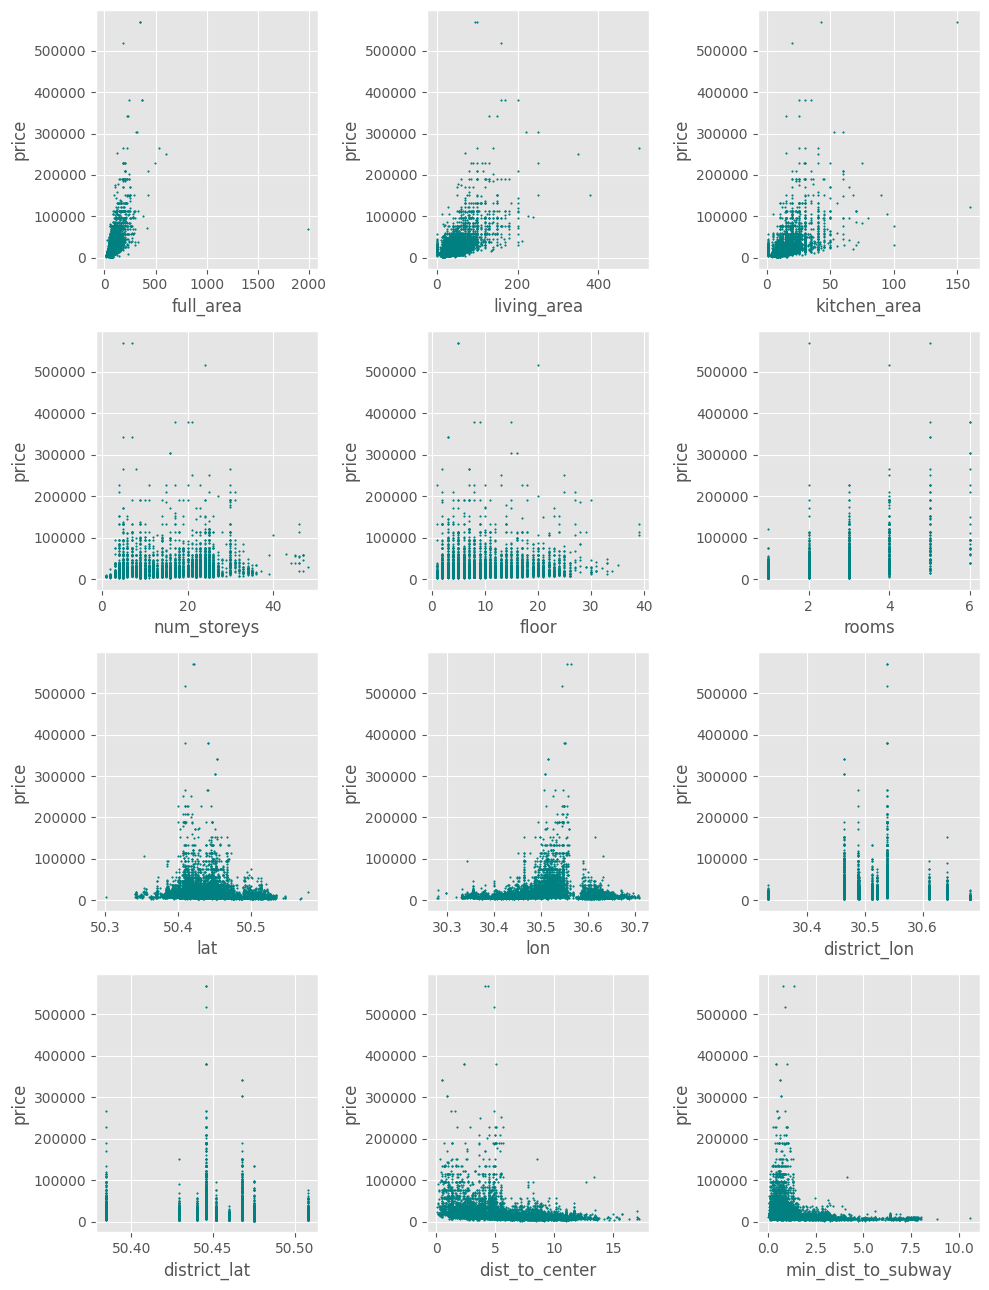

In [ ]:
f, ax = plt.subplots(4, 3, figsize=(10, 13))
k = 0
for i in range(4):
    for j in range(3):
        if k < 12:
            ax[i][j].scatter(x=countinious_feats[k], y='price', data=data, s=1, color='teal')
            ax[i][j].set_xlabel(countinious_feats[k])
            ax[i][j].set_ylabel('price')
            k += 1

plt.tight_layout()
plt.show()

`floor`

In [ ]:
data['floor'].value_counts().sort_index().reset_index()

,floor,count
0,1,322
1,2,565
2,3,650
3,4,661
4,5,597
5,6,433
6,7,423
7,8,392
8,9,395
9,10,324


In [ ]:
data['floor_other'] = data['floor'].apply(lambda x: 30 if x > 26 else x)

In [ ]:
data['floor_other'].value_counts().sort_index().reset_index()

,floor_other,count
0,1,322
1,2,565
2,3,650
3,4,661
4,5,597
5,6,433
6,7,423
7,8,392
8,9,395
9,10,324


In [ ]:
feats_floor_other = feats_new + ['subway', 'floor_other']
feats_floor_other.remove('floor')
feats_floor_other

['rooms',
 'full_area',
 'living_area',
 'kitchen_area',
 'num_storeys',
 'typical_panel',
 'concrete_monolithic',
 'old_brick',
 'first_rental',
 'adjacent_separate',
 'ukrainian_brick',
 'eurorenovation',
 'satisfactory_condition',
 'multilevel',
 'needs_cosmetic_repairs',
 'kitchen_living_room',
 'penthouse',
 'old_panel',
 'good_condition',
 'pre_revolutionary',
 'needs_major_repairs',
 'gas_block',
 'repair_in_progress',
 'free_planning',
 'adjacent',
 'separate',
 'ukrainian_panel',
 'Stalinka',
 'excellent_condition',
 'studio',
 'designer_renovation',
 'safe',
 'shower_cabin',
 'wardrobe',
 'TV',
 'hair_dryer',
 'dishes',
 'satellite_TV',
 'DVD_player',
 'washing_machine',
 'fireplace',
 'dishwashers',
 'alarms',
 'bed',
 'counters',
 'air_conditioning',
 'refrigerator',
 'jacuzzi',
 'microwave',
 'iron',
 'cable_TV',
 'lat',
 'lon',
 'district_lat',
 'district_lon',
 'min_dist_to_subway',
 'dist_to_center',
 'district',
 'subway',
 'floor_other']

In [ ]:
X, y = get_X_y(data, feats_floor_other)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3667, test_rmsle: 0.3838
[Fold 1] train_rmsle: 0.3623, test_rmsle: 0.3769
[Fold 2] train_rmsle: 0.3679, test_rmsle: 0.3635
[Fold 3] train_rmsle: 0.3648, test_rmsle: 0.3664
[Fold 4] train_rmsle: 0.3608, test_rmsle: 0.3817
RMSLE: 0.3745 ± 0.0081


Previous: 0.3716 ± 0.0080

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3043, test_rmsle: 0.3256
[Fold 1] train_rmsle: 0.3058, test_rmsle: 0.3191
[Fold 2] train_rmsle: 0.3100, test_rmsle: 0.3045
[Fold 3] train_rmsle: 0.3098, test_rmsle: 0.3098
[Fold 4] train_rmsle: 0.3088, test_rmsle: 0.3256
RMSLE: 0.3169 ± 0.0085


Previous result: 0.3177 ± 0.0088

For logarithm price `floor_other` give better result, but for simple price - worse.

`num_storeys`

In [ ]:
data['num_storeys'].value_counts().sort_index().reset_index()

,num_storeys,count
0,1,9
1,2,26
2,3,41
3,4,154
4,5,806
5,6,133
6,7,118
7,8,75
8,9,1213
9,10,212


In [ ]:
data['num_storeys_other'] = data['num_storeys'].apply(lambda x: 40 if x > 35 else x)
data['num_storeys_other'].value_counts().sort_index().reset_index()

,num_storeys_other,count
0,1,9
1,2,26
2,3,41
3,4,154
4,5,806
5,6,133
6,7,118
7,8,75
8,9,1213
9,10,212


In [ ]:
feats_floor_numstoreys_other = feats_floor_other + ['num_storeys_other']
feats_floor_numstoreys_other.remove('num_storeys')

X, y = get_X_y(data, feats_floor_numstoreys_other)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3613, test_rmsle: 0.3808
[Fold 1] train_rmsle: 0.3598, test_rmsle: 0.3721
[Fold 2] train_rmsle: 0.3707, test_rmsle: 0.3641
[Fold 3] train_rmsle: 0.3588, test_rmsle: 0.3595
[Fold 4] train_rmsle: 0.3609, test_rmsle: 0.3826
RMSLE: 0.3718 ± 0.0090


Previous: 0.3716 ± 0.0080

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3064, test_rmsle: 0.3258
[Fold 1] train_rmsle: 0.3060, test_rmsle: 0.3193
[Fold 2] train_rmsle: 0.3108, test_rmsle: 0.3053
[Fold 3] train_rmsle: 0.3107, test_rmsle: 0.3105
[Fold 4] train_rmsle: 0.3077, test_rmsle: 0.3242
RMSLE: 0.3170 ± 0.0079


Previous result: 0.3177 ± 0.0088

For logarithm price `floor_other` and `num_storeys_other` give better result, but for simple price - worse.

`full_area`

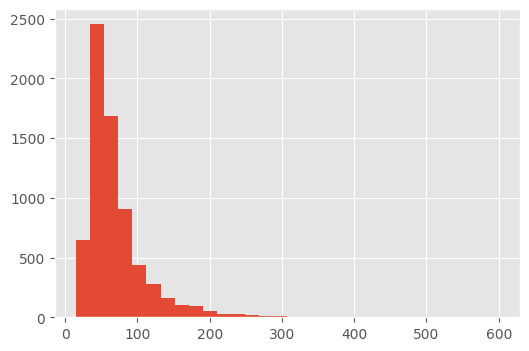

In [ ]:
data['full_area'].hist(bins=30);

In [ ]:
data[data['full_area'] > 300][['price', 'rooms', 'full_area']]

,price,rooms,full_area
233,570000,5,350.0
1319,266000,6,530.0
1320,152000,5,430.0
2169,380000,6,368.0
2170,72200,6,420.0
2277,250800,5,600.0
2889,114000,5,330.0
3573,570000,2,350.0
3677,380000,6,364.0
3754,95000,6,303.0


In [ ]:
data.loc[3358, 'description']

'Актуально! New!\n\nАренда стильной 5-к квартиры в центре Киева\nПлощадь: 203м2\nЭтаж: 4/5 (есть лифт), (поднимается только вверх)\nАдрес: Антоновича (Горького) 18\nБлижайшая станция метро: Льва Толстого в 3 минутах ходьбы\n4 отдельные спальни(без мебели), большая кухня гостиная, 2 санузла\nИмпортная дорогая встроенная мебель\n\nЦена: 1800$ (на период военного положения).\nВозможна оплата: Наличными, безнал'

In [ ]:
data.loc[3358, 'full_area'] = 203 # fix error

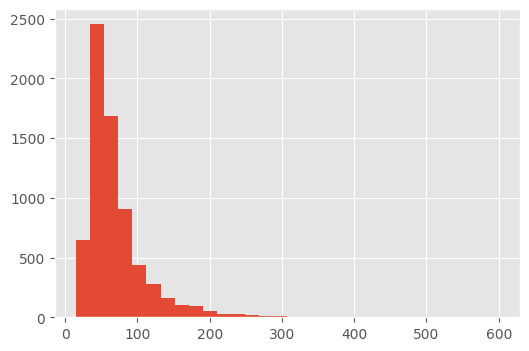

In [ ]:
data['full_area'].hist(bins=30);

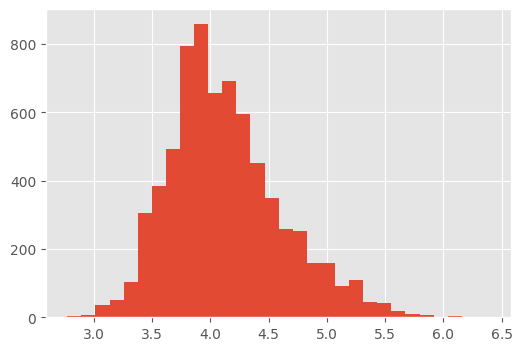

In [ ]:
data['full_area_log'] = np.log1p(data['full_area'])
data['full_area_log'].hist(bins=30);

In [ ]:
feats_full_area_log = feats_new + ['subway', 'full_area_log']
feats_full_area_log.remove('full_area')

X, y = get_X_y(data, feats_full_area_log)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3600, test_rmsle: 0.3789
[Fold 1] train_rmsle: 0.3642, test_rmsle: 0.3745
[Fold 2] train_rmsle: 0.3708, test_rmsle: 0.3660
[Fold 3] train_rmsle: 0.3601, test_rmsle: 0.3593
[Fold 4] train_rmsle: 0.3573, test_rmsle: 0.3796
RMSLE: 0.3717 ± 0.0079


Previous: 0.3716 ± 0.0080

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3038, test_rmsle: 0.3250
[Fold 1] train_rmsle: 0.3060, test_rmsle: 0.3201
[Fold 2] train_rmsle: 0.3118, test_rmsle: 0.3071
[Fold 3] train_rmsle: 0.3109, test_rmsle: 0.3102
[Fold 4] train_rmsle: 0.3077, test_rmsle: 0.3256
RMSLE: 0.3176 ± 0.0076


Previous result: 0.3177 ± 0.0088

In [ ]:
feats_full_area_log = feats_new + ['subway', 'full_area_log']
feats_full_area_log.remove('full_area')

X, y = get_X_y(data, feats_full_area_log)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3650, test_rmsle: 0.3848
[Fold 1] train_rmsle: 0.3628, test_rmsle: 0.3740
[Fold 2] train_rmsle: 0.3698, test_rmsle: 0.3606
[Fold 3] train_rmsle: 0.3689, test_rmsle: 0.3697
[Fold 4] train_rmsle: 0.3597, test_rmsle: 0.3818
RMSLE: 0.3742 ± 0.0086


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3037, test_rmsle: 0.3231
[Fold 1] train_rmsle: 0.3061, test_rmsle: 0.3212
[Fold 2] train_rmsle: 0.3130, test_rmsle: 0.3057
[Fold 3] train_rmsle: 0.3089, test_rmsle: 0.3109
[Fold 4] train_rmsle: 0.3081, test_rmsle: 0.3273
RMSLE: 0.3176 ± 0.0081


In [ ]:
feats_full_area_log = feats_floor_numstoreys_other + ['full_area_log']
feats_full_area_log.remove('full_area')

X, y = get_X_y(data, feats_full_area_log)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3568, test_rmsle: 0.3773
[Fold 1] train_rmsle: 0.3598, test_rmsle: 0.3739
[Fold 2] train_rmsle: 0.3695, test_rmsle: 0.3664
[Fold 3] train_rmsle: 0.3566, test_rmsle: 0.3569
[Fold 4] train_rmsle: 0.3576, test_rmsle: 0.3779
RMSLE: 0.3705 ± 0.0079


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3063, test_rmsle: 0.3239
[Fold 1] train_rmsle: 0.3086, test_rmsle: 0.3247
[Fold 2] train_rmsle: 0.3113, test_rmsle: 0.3042
[Fold 3] train_rmsle: 0.3093, test_rmsle: 0.3092
[Fold 4] train_rmsle: 0.3083, test_rmsle: 0.3265
RMSLE: 0.3177 ± 0.0092


For logarithm price `floor_other` and `num_storeys_other` give the same result, but for simple price - the best.

`living_area`

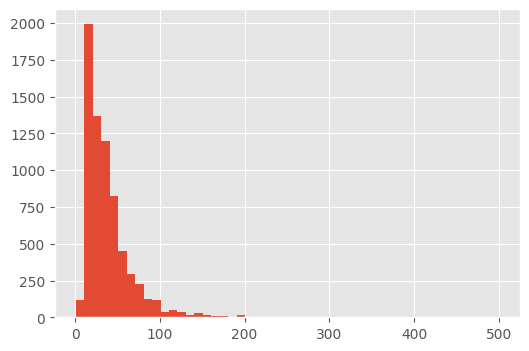

In [ ]:
data['living_area'].hist(bins=50);

In [ ]:
data[data['living_area'] > 200][['price', 'rooms', 'full_area', 'living_area']]

,price,rooms,full_area,living_area
1235,152000,5,290.0,250.0
1319,266000,6,530.0,500.0
1320,152000,5,430.0,380.0
2277,250800,5,600.0,350.0
4069,39800,6,270.0,210.0
4403,98800,4,279.0,239.0
4773,304000,6,320.0,250.0
5609,228000,6,490.0,250.0
6139,100000,5,380.0,225.0
6530,304000,6,310.0,220.0


In [ ]:
data[data['living_area'] < 10][['price', 'rooms', 'full_area', 'living_area']]

,price,rooms,full_area,living_area
104,5800,1,15.0,9.0
367,15900,1,40.0,1.0
606,34200,2,67.0,1.0
654,20000,2,42.0,1.0
657,24700,2,50.0,1.0
...,...,...,...,...
6454,22800,2,50.0,1.0
6540,11900,1,26.0,6.0
6549,12000,1,24.0,5.0
6860,15000,1,31.0,9.0


In [ ]:
data['living_area_fix'] = data['living_area'].apply(lambda x: None if x == 1 else x)

In [ ]:
data[data['living_area_fix'] < 10][['price', 'rooms', 'full_area', 'living_area_fix']]

,price,rooms,full_area,living_area_fix
104,5800,1,15.0,9.0
841,20900,2,50.0,8.0
1075,10000,1,30.0,7.0
1715,7500,1,25.0,8.0
2338,6500,1,38.0,8.0
2362,8000,1,24.0,9.0
2719,8000,1,23.0,5.0
3504,13000,1,24.0,4.0
3663,26600,1,53.0,7.0
3788,8000,1,45.0,8.0


In [ ]:
data['living_area_fix'].isna().sum()

82

Fill NaN values with median within group apatrments by 'rooms', 'full_area', 'district'.

In [ ]:
data.groupby(['rooms', 'full_area', 'num_storeys_other'])['living_area_fix'].median().reset_index().sort_values('living_area_fix')

,rooms,full_area,num_storeys_other,living_area_fix
45,1,24.0,18,4.0
39,1,23.0,22,5.0
46,1,24.0,21,5.0
65,1,26.0,17,6.0
0,1,15.0,5,9.0
...,...,...,...,...
2093,3,135.0,24,NaN
2263,4,120.0,25,NaN
2304,4,137.0,19,NaN
2404,4,180.0,5,NaN


In [ ]:
data['living_area_fix'] = (data['living_area_fix']
                           .fillna(data.groupby(['rooms', 'full_area', 'num_storeys_other'])['living_area_fix']
                           .transform('median')))

In [ ]:
data[data['living_area_fix'] < 10][['price', 'rooms', 'full_area', 'living_area_fix']]

,price,rooms,full_area,living_area_fix
104,5800,1,15.0,9.0
841,20900,2,50.0,8.0
1075,10000,1,30.0,7.0
1715,7500,1,25.0,8.0
2338,6500,1,38.0,8.0
2362,8000,1,24.0,9.0
2719,8000,1,23.0,5.0
3504,13000,1,24.0,4.0
3663,26600,1,53.0,7.0
3788,8000,1,45.0,8.0


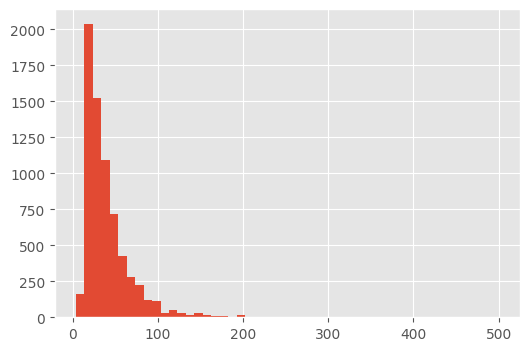

In [ ]:
data['living_area_fix'].hist(bins=50);

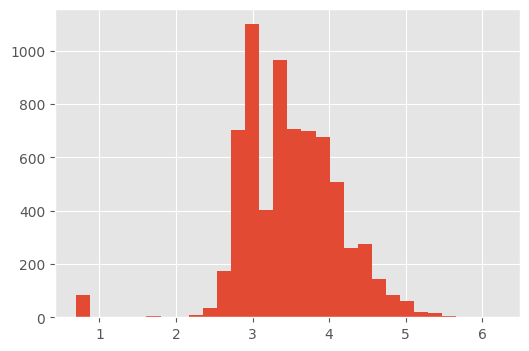

In [ ]:
data['living_area_log'] = np.log1p(data['living_area'])
data['living_area_log'].hist(bins=30);

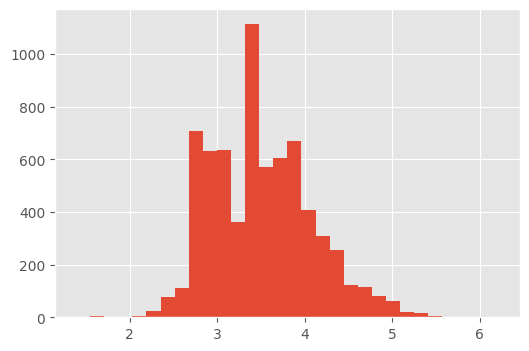

In [ ]:
data['living_area_fix_log'] = np.log(data['living_area_fix'])
data['living_area_fix_log'].hist(bins=30);

In [ ]:
data[data['living_area_fix_log'] < 2][['price', 'rooms', 'full_area', 'living_area_fix']]

,price,rooms,full_area,living_area_fix
1075,10000,1,30.0,7.0
2719,8000,1,23.0,5.0
3504,13000,1,24.0,4.0
3663,26600,1,53.0,7.0
6261,9000,1,20.0,5.0
6540,11900,1,26.0,6.0
6549,12000,1,24.0,5.0


In [ ]:
black_list = ['id', 'price', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data.columns if data[col].dtypes != 'object' and col not in black_list]

In [ ]:
feats_full_area_log = num_feats + ['subway', 'district']
for_delete = ['floor', 'full_area', 'num_storeys', 'living_area_fix', 'living_area_fix_log', 'living_area_log']
feats_full_area_log = [x for x in feats_full_area_log if x not in for_delete]
len(feats_full_area_log)

60

In [ ]:
feats_full_living_area_log = feats_full_area_log + ['living_area_log']
feats_full_living_area_log.remove('living_area')

X, y = get_X_y(data, feats_full_living_area_log)

parameters = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.1,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
}
model = xgb.XGBRegressor(**parameters)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3638, test_rmsle: 0.3818
[Fold 1] train_rmsle: 0.3619, test_rmsle: 0.3748
[Fold 2] train_rmsle: 0.3703, test_rmsle: 0.3697
[Fold 3] train_rmsle: 0.3626, test_rmsle: 0.3609
[Fold 4] train_rmsle: 0.3604, test_rmsle: 0.3827
RMSLE: 0.3740 ± 0.0081


Previous: 0.3716 ± 0.0080

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3054, test_rmsle: 0.3269
[Fold 1] train_rmsle: 0.3091, test_rmsle: 0.3241
[Fold 2] train_rmsle: 0.3102, test_rmsle: 0.3040
[Fold 3] train_rmsle: 0.3064, test_rmsle: 0.3069
[Fold 4] train_rmsle: 0.3070, test_rmsle: 0.3238
RMSLE: 0.3172 ± 0.0096


Previous result: 0.3177 ± 0.0088

For logarithm price `living_area_log` give better result, but for simple price worst.

In [ ]:
feats_full_living_area_fix_log = feats_full_area_log + ['living_area_fix_log']

X, y = get_X_y(data, feats_full_living_area_fix_log)

model = xgb.XGBRegressor(**parameters)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3623, test_rmsle: 0.3798
[Fold 1] train_rmsle: 0.3599, test_rmsle: 0.3713
[Fold 2] train_rmsle: 0.3700, test_rmsle: 0.3651
[Fold 3] train_rmsle: 0.3673, test_rmsle: 0.3658
[Fold 4] train_rmsle: 0.3647, test_rmsle: 0.3857
RMSLE: 0.3736 ± 0.0080


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3063, test_rmsle: 0.3284
[Fold 1] train_rmsle: 0.3067, test_rmsle: 0.3215
[Fold 2] train_rmsle: 0.3110, test_rmsle: 0.3054
[Fold 3] train_rmsle: 0.3111, test_rmsle: 0.3130
[Fold 4] train_rmsle: 0.3073, test_rmsle: 0.3241
RMSLE: 0.3185 ± 0.0082


logarithm of living_area and living_area_fix give worst result

In [ ]:
feats_full_log_living_area_fix = feats_full_area_log + ['living_area_fix']

X, y = get_X_y(data, feats_full_log_living_area_fix)

model = xgb.XGBRegressor(**parameters)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3623, test_rmsle: 0.3798
[Fold 1] train_rmsle: 0.3599, test_rmsle: 0.3713
[Fold 2] train_rmsle: 0.3700, test_rmsle: 0.3651
[Fold 3] train_rmsle: 0.3673, test_rmsle: 0.3658
[Fold 4] train_rmsle: 0.3647, test_rmsle: 0.3857
RMSLE: 0.3736 ± 0.0080


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3063, test_rmsle: 0.3284
[Fold 1] train_rmsle: 0.3067, test_rmsle: 0.3215
[Fold 2] train_rmsle: 0.3110, test_rmsle: 0.3054
[Fold 3] train_rmsle: 0.3111, test_rmsle: 0.3130
[Fold 4] train_rmsle: 0.3073, test_rmsle: 0.3241
RMSLE: 0.3185 ± 0.0082


Worst result with `living_area_fix`

In [ ]:
del data['living_area_fix']
del data['living_area_fix_log']

`kitchen_area`

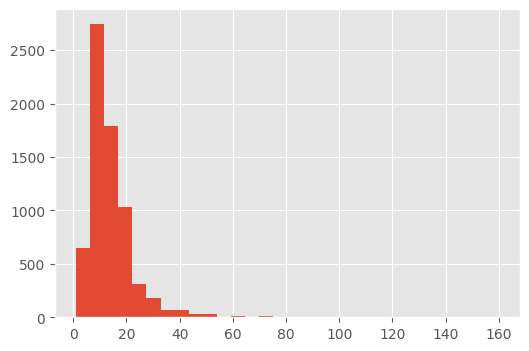

In [ ]:
data['kitchen_area'].hist(bins=30);

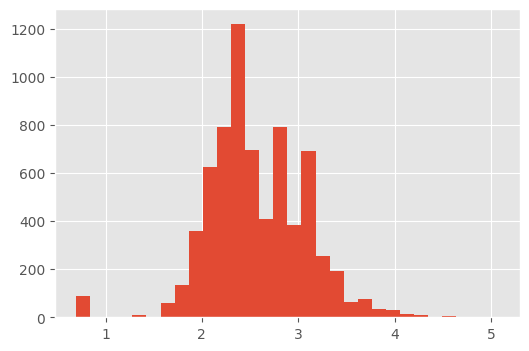

In [ ]:
data['kitchen_area_log'] = np.log1p(data['kitchen_area'])
data['kitchen_area_log'].hist(bins=30);

In [ ]:
feats_full_living_area_log = feats_full_area_log + ['kitchen_area_log']
feats_full_living_area_log.remove('kitchen_area')

X, y = get_X_y(data, feats_full_living_area_log)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3578, test_rmsle: 0.3789
[Fold 1] train_rmsle: 0.3605, test_rmsle: 0.3762
[Fold 2] train_rmsle: 0.3716, test_rmsle: 0.3678
[Fold 3] train_rmsle: 0.3642, test_rmsle: 0.3635
[Fold 4] train_rmsle: 0.3601, test_rmsle: 0.3797
RMSLE: 0.3732 ± 0.0064


Previous: 0.3716 ± 0.0080

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3049, test_rmsle: 0.3258
[Fold 1] train_rmsle: 0.3067, test_rmsle: 0.3212
[Fold 2] train_rmsle: 0.3116, test_rmsle: 0.3062
[Fold 3] train_rmsle: 0.3107, test_rmsle: 0.3096
[Fold 4] train_rmsle: 0.3077, test_rmsle: 0.3245
RMSLE: 0.3174 ± 0.0080


Previous result: 0.3177 ± 0.0088

Worse results.

### First floor, last and one before last floor

In [ ]:
print('First floor:', data[data['floor'] == 1].shape[0])
print('Last floor:', data[data['floor'] == data['num_storeys']].shape[0])
print('One before last floor:', data[data['floor'] == (data['num_storeys'] - 1) ].shape[0])

First floor: 322
Last floor: 606
One before last floor: 668


In [ ]:
data['apartament_last_floor'] = data['floor'] == data['num_storeys']
data['apartament_one_before_last_floor'] = data['floor'] == (data['num_storeys'] - 1)
data['apartament_first_floor'] = data['floor'] == 1

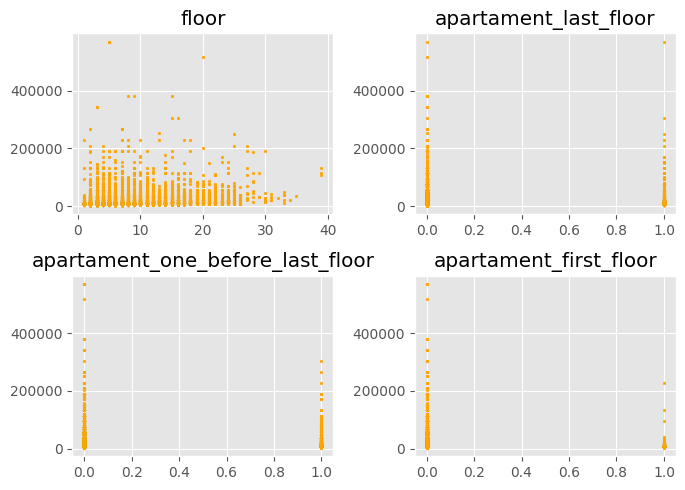

In [ ]:
plt.figure(figsize=(7, 5))
keys = ['floor', 'apartament_last_floor', 'apartament_one_before_last_floor', 'apartament_first_floor']
for i, key in enumerate(keys):
    plt.subplot(2, 2, i+1)
    plt.scatter(data[key], data["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
black_list = ['id', 'price', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data.columns if data[col].dtypes != 'object' and col not in black_list]

In [ ]:
del_for_log_feats = ['full_area', 'living_area', 'kitchen_area',  'floor', 'num_storeys']
feats = [x for x in num_feats if x not in del_for_log_feats]

In [ ]:
X, y = get_X_y(data, feats + ['subway', 'district'])

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3625, test_rmsle: 0.3803
[Fold 1] train_rmsle: 0.3619, test_rmsle: 0.3732
[Fold 2] train_rmsle: 0.3645, test_rmsle: 0.3546
[Fold 3] train_rmsle: 0.3640, test_rmsle: 0.3656
[Fold 4] train_rmsle: 0.3556, test_rmsle: 0.3770
RMSLE: 0.3701 ± 0.0092


Best result without log price

In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3066, test_rmsle: 0.3266
[Fold 1] train_rmsle: 0.3091, test_rmsle: 0.3253
[Fold 2] train_rmsle: 0.3146, test_rmsle: 0.3089
[Fold 3] train_rmsle: 0.3126, test_rmsle: 0.3093
[Fold 4] train_rmsle: 0.3087, test_rmsle: 0.3273
RMSLE: 0.3195 ± 0.0085


In [ ]:
del_for_log_feats = ['full_area', 'living_area', 'kitchen_area',  'floor_other', 'num_storeys_other']
feats = [x for x in num_feats if x not in del_for_log_feats]

X, y = get_X_y(data, feats + ['subway', 'district'])

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3637, test_rmsle: 0.3802
[Fold 1] train_rmsle: 0.3606, test_rmsle: 0.3764
[Fold 2] train_rmsle: 0.3672, test_rmsle: 0.3621
[Fold 3] train_rmsle: 0.3630, test_rmsle: 0.3615
[Fold 4] train_rmsle: 0.3603, test_rmsle: 0.3847
RMSLE: 0.3730 ± 0.0095


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3068, test_rmsle: 0.3284
[Fold 1] train_rmsle: 0.3067, test_rmsle: 0.3216
[Fold 2] train_rmsle: 0.3098, test_rmsle: 0.3050
[Fold 3] train_rmsle: 0.3094, test_rmsle: 0.3109
[Fold 4] train_rmsle: 0.3084, test_rmsle: 0.3265
RMSLE: 0.3185 ± 0.0091


In [ ]:
del_without_log_feats = ['full_area_log', 'living_area_log', 'kitchen_area_log', 'floor', 'num_storeys']
feats = [x for x in num_feats if x not in del_without_log_feats]

In [ ]:
X, y = get_X_y(data, feats + ['subway', 'district'])

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3607, test_rmsle: 0.3766
[Fold 1] train_rmsle: 0.3545, test_rmsle: 0.3705
[Fold 2] train_rmsle: 0.3662, test_rmsle: 0.3625
[Fold 3] train_rmsle: 0.3654, test_rmsle: 0.3649
[Fold 4] train_rmsle: 0.3590, test_rmsle: 0.3821
RMSLE: 0.3713 ± 0.0073


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3055, test_rmsle: 0.3246
[Fold 1] train_rmsle: 0.3073, test_rmsle: 0.3234
[Fold 2] train_rmsle: 0.3126, test_rmsle: 0.3045
[Fold 3] train_rmsle: 0.3095, test_rmsle: 0.3077
[Fold 4] train_rmsle: 0.3049, test_rmsle: 0.3209
RMSLE: 0.3162 ± 0.0084


Best result for log price

In [ ]:
del_without_log_feats = ['full_area_log', 'living_area_log', 'kitchen_area_log', 'floor_other', 'num_storeys_other']
feats = [x for x in num_feats if x not in del_without_log_feats]

X, y = get_X_y(data, feats + ['subway', 'district'])

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

model = xgb.XGBRegressor(**parameters)

run_cv(pipeline, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3629, test_rmsle: 0.3805
[Fold 1] train_rmsle: 0.3601, test_rmsle: 0.3745
[Fold 2] train_rmsle: 0.3713, test_rmsle: 0.3680
[Fold 3] train_rmsle: 0.3626, test_rmsle: 0.3607
[Fold 4] train_rmsle: 0.3568, test_rmsle: 0.3793
RMSLE: 0.3726 ± 0.0074


In [ ]:
run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3058, test_rmsle: 0.3274
[Fold 1] train_rmsle: 0.3070, test_rmsle: 0.3220
[Fold 2] train_rmsle: 0.3123, test_rmsle: 0.3050
[Fold 3] train_rmsle: 0.3115, test_rmsle: 0.3104
[Fold 4] train_rmsle: 0.3087, test_rmsle: 0.3247
RMSLE: 0.3179 ± 0.0087


### Target Encoding

In [ ]:
data_target_enc = data.copy()

In [ ]:
class TargetFeatureEncoding:
    def __init__(self, C=10):
        self.C = C
        self.cpu_k = 3
        self.global_mean = 0
        self.features = 'all'
        self.cat_columns = []
        self.y = 0
        self.values = dict()

    def fit(self, data, y, features='all'):

        self.y = y

        if features == 'all':
            self.cat_columns = sorted([i for i in data.columns if data[i].dtype == 'O'])
            self.features = self.cat_columns
        else:
            self.features = features

        self.global_mean = np.mean(y)

        f = {'y': ['size', 'mean']}

        for col in self.features:
            self.values[col] = dict()
            temp = pd.DataFrame({'y': y, col: data[col]}).groupby([col]).agg(f)

            self.values[col] = (
                (temp['y']['mean'] * temp['y']['size'] + self.global_mean * self.C) /
                (temp['y']['size'] + self.C)
            ).to_dict()

        return self.values

    def fit_transform(self, data, y, features='all', inplace=True):

        self.fit(data, y, features)
        return self.transform(data, inplace=inplace)

    def transform(self, data, inplace=True):
        import warnings

        if inplace:
            for col in self.values:
                if col in data.columns:
                    temp = pd.DataFrame.from_dict(
                        self.values[col], orient='index').reset_index()
                    temp.columns = [col, 'value']
                    data = pd.merge(data, temp, how='left').fillna(self.global_mean)
                    data[col] = data['value']
                    del data['value']
                    data[col] = data[col].astype('float32')

                else:
                    warnings.warn('Column ' + col + ' is missed in this dataset.')
        else:
            new_data = data.copy()
            for col in self.values:
                if col in new_data.columns:
                    temp = pd.DataFrame.from_dict(
                        self.values[col], orient='index').reset_index()
                    temp.columns = [col, 'value']
                    new_data = pd.merge(
                        new_data, temp, how='left').fillna(self.global_mean)
                    new_data[col] = new_data['value']
                    del new_data['value']
                    new_data[col] = new_data[col].astype('float32')

                else:
                    warnings.warn('Column ' + col + ' is missed in this dataset.')
            return new_data


def create_new_df_with_categorical_encodings(new_train, new_train_y, new_val, cols):
    se = TargetFeatureEncoding()
    new_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    val_dfs = []
    # 2)
    for new_train_split, new_val_split in new_skf.split(new_train, new_train_y):
        # 3)
        se.fit(
            new_train.iloc[new_train_split],
            new_train_y.iloc[new_train_split],
            features=cols
        )
        val_dfs.append(
            se.transform(new_train.iloc[new_val_split], inplace=False)
        )
    # 4)
    se.fit(new_train, new_train_y, features=cols)
    main_val = se.transform(new_val, inplace=False)
    return val_dfs, main_val

In [ ]:
features = ['district', 'subway']

In [ ]:
%%time

new_train_dfs = []
new_val_dfs = []
main_train_dfs = []

for train_split, val_split in skf.split(X, X['rooms']):
    # 5)
    temp_train_dfs, temp_val_df = create_new_df_with_categorical_encodings(
        data_target_enc.iloc[train_split],
        y.iloc[train_split],
        data_target_enc.iloc[val_split],
        features
    )
    # 6)
    new_train_dfs.append(temp_train_dfs)
    new_val_dfs.append(temp_val_df)
    # 7)
    se = TargetFeatureEncoding()
    se.fit(data_target_enc.iloc[train_split], y.iloc[train_split], features)
    main_train_dfs.append(
        se.transform(data_target_enc.iloc[val_split], inplace=False)
    )

se.fit_transform(X, y, features=features)
#main_test = se.transform(X_test, inplace=False)

d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


CPU times: total: 1 s
Wall time: 1.3 s


d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


In [ ]:
data_te = pd.concat([i for i in main_train_dfs], axis=0, ignore_index=True)

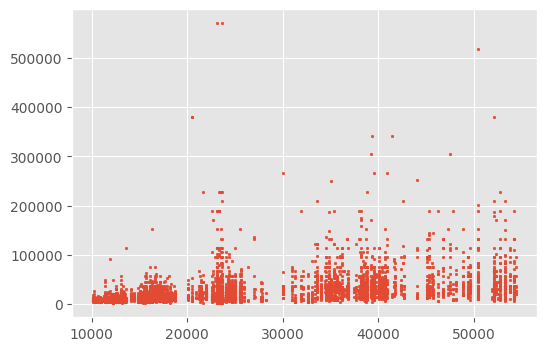

In [ ]:
plt.scatter(data_te['subway'], data_te['price'], s=3);

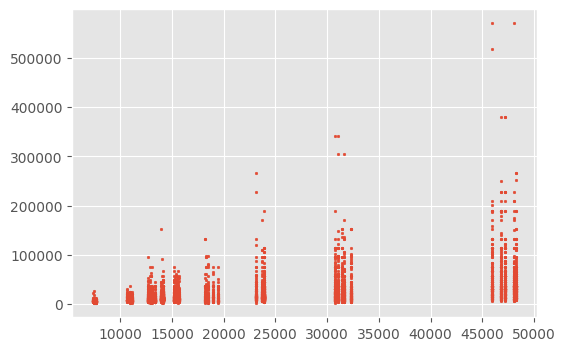

In [ ]:
plt.scatter(data_te['district'], data_te['price'], s=3);

In [ ]:
data_te['subway'].astype('float')
data_te['district'].astype('float')

0       10921.110352
1       15345.629883
2       47210.707031
3       32334.634766
4       15345.629883
            ...     
6932    14147.239258
6933    18495.017578
6934    46790.964844
6935    10931.741211
6936    10931.741211
Name: district, Length: 6937, dtype: float64

In [ ]:
black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te.columns if data_te[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te, num_feats)

model = xgb.XGBRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3667, test_rmsle: 0.3540
[Fold 1] train_rmsle: 0.3574, test_rmsle: 0.3740
[Fold 2] train_rmsle: 0.3555, test_rmsle: 0.3703
[Fold 3] train_rmsle: 0.3606, test_rmsle: 0.3685
[Fold 4] train_rmsle: 0.3552, test_rmsle: 0.3775
RMSLE: 0.3689 ± 0.0081


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3093, test_rmsle: 0.2931
[Fold 1] train_rmsle: 0.3012, test_rmsle: 0.3186
[Fold 2] train_rmsle: 0.3028, test_rmsle: 0.3297
[Fold 3] train_rmsle: 0.3053, test_rmsle: 0.3019
[Fold 4] train_rmsle: 0.3023, test_rmsle: 0.3237
RMSLE: 0.3134 ± 0.0137


**The best result!**

In [ ]:
data_te.to_csv('../data/real_estate_target_enc.csv', index=False)

### Feature Interactions with xgbfir

In [ ]:

black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te.columns if data_te[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te, num_feats)

xgb_train = xgb.DMatrix(X, y)

num_rounds = 1_000
results = xgb.cv(parameters, xgb_train, num_rounds,
                 folds=skf, early_stopping_rounds=10, verbose_eval=50)


[0]	train-rmsle:2.19485+0.01107	test-rmsle:2.19481+0.01856


d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[50]	train-rmsle:0.38773+0.00533	test-rmsle:0.39496+0.00426
[100]	train-rmsle:0.35679+0.00508	test-rmsle:0.36676+0.00511
[150]	train-rmsle:0.34738+0.00516	test-rmsle:0.35971+0.00532
[200]	train-rmsle:0.34090+0.00383	test-rmsle:0.35501+0.00623
[250]	train-rmsle:0.33543+0.00422	test-rmsle:0.35192+0.00611
[300]	train-rmsle:0.32912+0.00413	test-rmsle:0.34678+0.00684
[350]	train-rmsle:0.32443+0.00372	test-rmsle:0.34298+0.00628
[400]	train-rmsle:0.32034+0.00312	test-rmsle:0.34053+0.00690
[414]	train-rmsle:0.31970+0.00337	test-rmsle:0.34081+0.00705


In [ ]:
model = xgb.train(parameters, xgb_train, num_boost_round=415)
xgbfir.saveXgbFI(
    model,
    feature_names=num_feats,
    OutputXlsxFile=pjoin("../data", "xgbfir_importance.xlsx")
)

In [ ]:
data_te_fir = data_te.copy()

In [ ]:
data_te_fir['full_area|subway'] = data_te_fir['subway'] * data_te_fir['full_area']

black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te_fir.columns if data_te_fir[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te_fir, num_feats)

model = xgb.XGBRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3648, test_rmsle: 0.3571
[Fold 1] train_rmsle: 0.3555, test_rmsle: 0.3781
[Fold 2] train_rmsle: 0.3520, test_rmsle: 0.3657
[Fold 3] train_rmsle: 0.3604, test_rmsle: 0.3696
[Fold 4] train_rmsle: 0.3520, test_rmsle: 0.3682
RMSLE: 0.3677 ± 0.0067


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3092, test_rmsle: 0.2965
[Fold 1] train_rmsle: 0.3026, test_rmsle: 0.3200
[Fold 2] train_rmsle: 0.3030, test_rmsle: 0.3260
[Fold 3] train_rmsle: 0.3088, test_rmsle: 0.3053
[Fold 4] train_rmsle: 0.3041, test_rmsle: 0.3212
RMSLE: 0.3138 ± 0.0111


In [ ]:
data_te_fir['full_area|subway'] = data_te_fir['subway'] * data_te_fir['full_area']
data_te_fir['full_area_log|kitchen_area_log'] = data_te_fir['kitchen_area_log'] / data_te_fir['full_area_log']

black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te_fir.columns if data_te_fir[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te_fir, num_feats)

model = xgb.XGBRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3593, test_rmsle: 0.3503
[Fold 1] train_rmsle: 0.3556, test_rmsle: 0.3803
[Fold 2] train_rmsle: 0.3491, test_rmsle: 0.3643
[Fold 3] train_rmsle: 0.3556, test_rmsle: 0.3665
[Fold 4] train_rmsle: 0.3531, test_rmsle: 0.3692
RMSLE: 0.3661 ± 0.0096


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3098, test_rmsle: 0.2949
[Fold 1] train_rmsle: 0.3032, test_rmsle: 0.3216
[Fold 2] train_rmsle: 0.3035, test_rmsle: 0.3287
[Fold 3] train_rmsle: 0.3070, test_rmsle: 0.3064
[Fold 4] train_rmsle: 0.3046, test_rmsle: 0.3236
RMSLE: 0.3151 ± 0.0125


In [ ]:
data_te_fir['full_area|subway'] = data_te_fir['subway'] * data_te_fir['full_area']
data_te_fir['full_area_log|kitchen_area_log'] = data_te_fir['kitchen_area_log'] / data_te_fir['full_area_log']
data_te_fir['full_area|kitchen_area'] = data_te_fir['kitchen_area'] + data_te_fir['full_area']

black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te_fir.columns if data_te_fir[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te_fir, num_feats)

model = xgb.XGBRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3613, test_rmsle: 0.3503
[Fold 1] train_rmsle: 0.3560, test_rmsle: 0.3794
[Fold 2] train_rmsle: 0.3544, test_rmsle: 0.3701
[Fold 3] train_rmsle: 0.3543, test_rmsle: 0.3600
[Fold 4] train_rmsle: 0.3558, test_rmsle: 0.3671
RMSLE: 0.3654 ± 0.0098


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3116, test_rmsle: 0.2959
[Fold 1] train_rmsle: 0.3045, test_rmsle: 0.3223
[Fold 2] train_rmsle: 0.3046, test_rmsle: 0.3282
[Fold 3] train_rmsle: 0.3063, test_rmsle: 0.3070
[Fold 4] train_rmsle: 0.3057, test_rmsle: 0.3248
RMSLE: 0.3156 ± 0.0123


In [ ]:
data_te_fir = data_te.copy()

In [ ]:
data_te_fir['full_area|subway'] = data_te_fir['subway'] * data_te_fir['full_area']
data_te_fir['full_area_log|kitchen_area_log'] = data_te_fir['kitchen_area_log'] / data_te_fir['full_area_log']
data_te_fir['dist_to_center|full_area'] = data_te_fir['dist_to_center'] * data_te_fir['full_area']
data_te_fir['dist_to_center|kitchen_area'] = data_te_fir['dist_to_center'] * data_te_fir['kitchen_area']

black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data_te_fir.columns if data_te_fir[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te_fir, num_feats)

model = xgb.XGBRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3599, test_rmsle: 0.3487
[Fold 1] train_rmsle: 0.3565, test_rmsle: 0.3772
[Fold 2] train_rmsle: 0.3469, test_rmsle: 0.3624
[Fold 3] train_rmsle: 0.3553, test_rmsle: 0.3662
[Fold 4] train_rmsle: 0.3535, test_rmsle: 0.3670
RMSLE: 0.3643 ± 0.0092


**The best result**

In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3102, test_rmsle: 0.2958
[Fold 1] train_rmsle: 0.3052, test_rmsle: 0.3227
[Fold 2] train_rmsle: 0.3029, test_rmsle: 0.3261
[Fold 3] train_rmsle: 0.3078, test_rmsle: 0.3095
[Fold 4] train_rmsle: 0.3051, test_rmsle: 0.3234
RMSLE: 0.3155 ± 0.0114


In [ ]:
data_te_fir.to_csv('../data/real_estate_target_enc_fir.csv', index=False)

### LightGBM

In [ ]:
black_list = ['id', 'price', 'price_log', 'class', 'residential', 'detail', 'description', 'subway_old']
feats = [col for col in data_te_fir.columns if col not in black_list]
num_feats = [col for col in data_te_fir.columns if data_te_fir[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te_fir, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3331, test_rmsle: 0.3233
[Fold 1] train_rmsle: 0.2984, test_rmsle: 0.4410
[Fold 2] train_rmsle: 0.2977, test_rmsle: 0.3299
[Fold 3] train_rmsle: 0.3340, test_rmsle: 0.3231
[Fold 4] train_rmsle: 0.3255, test_rmsle: 0.3305
RMSLE: 0.3495 ± 0.0458


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2481, test_rmsle: 0.2693
[Fold 1] train_rmsle: 0.2410, test_rmsle: 0.2980
[Fold 2] train_rmsle: 0.2437, test_rmsle: 0.2876
[Fold 3] train_rmsle: 0.2452, test_rmsle: 0.2749
[Fold 4] train_rmsle: 0.2441, test_rmsle: 0.2885
RMSLE: 0.2837 ± 0.0103


In [ ]:
data_te = pd.read_csv('../data/real_estate_target_enc.csv')

In [ ]:
black_list = ['id', 'price']
feats = [col for col in data_te.columns if col not in black_list]
num_feats = [col for col in data_te.columns if data_te[col].dtypes != 'object' and col not in black_list]

X, y = get_X_y(data_te, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3119, test_rmsle: 0.3299
[Fold 1] train_rmsle: 0.3063, test_rmsle: 0.4362
[Fold 2] train_rmsle: 0.3340, test_rmsle: 0.3510
[Fold 3] train_rmsle: 0.3146, test_rmsle: 0.3326
[Fold 4] train_rmsle: 0.3085, test_rmsle: 0.3337
RMSLE: 0.3567 ± 0.0405


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2504, test_rmsle: 0.2660
[Fold 1] train_rmsle: 0.2429, test_rmsle: 0.2985
[Fold 2] train_rmsle: 0.2466, test_rmsle: 0.2870
[Fold 3] train_rmsle: 0.2478, test_rmsle: 0.2743
[Fold 4] train_rmsle: 0.2471, test_rmsle: 0.2899
RMSLE: 0.2831 ± 0.0115


In [ ]:
lgb_model = model.fit(X, np.log1p(y))

In [ ]:
show_weights(lgb_model, top=100)

Weight,Feature
0.1808,full_area_log
0.1587,kitchen_area
0.1400,full_area
0.1109,dist_to_center
0.0777,kitchen_area_log
0.0758,designer_renovation
0.0719,subway
0.0470,district
0.0236,min_dist_to_subway
0.0210,good_condition


In [ ]:
feats_to_drop = [
    'DVD_player', 'gas_block','apartament_one_before_last_floor',
    'wardrobe', 'TV', 'Stalinka', 'free_planning', 'needs_cosmetic_repairs',
    'repair_in_progress', 'penthouse', 'old_panel', 'needs_major_repairs'
    ]

In [ ]:
black_list = ['id', 'price']
feats = [col for col in data_te.columns if col not in black_list]
num_feats = [col for col in data_te.columns if data_te[col].dtypes != 'object' and col not in black_list and col not in feats_to_drop]

X, y = get_X_y(data_te, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3115, test_rmsle: 0.3338
[Fold 1] train_rmsle: 0.3071, test_rmsle: 0.4605
[Fold 2] train_rmsle: 0.3098, test_rmsle: 0.4549
[Fold 3] train_rmsle: 0.3114, test_rmsle: 0.3320
[Fold 4] train_rmsle: 0.3036, test_rmsle: 0.3329
RMSLE: 0.3828 ± 0.0612


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2505, test_rmsle: 0.2673
[Fold 1] train_rmsle: 0.2439, test_rmsle: 0.2962
[Fold 2] train_rmsle: 0.2462, test_rmsle: 0.2861
[Fold 3] train_rmsle: 0.2479, test_rmsle: 0.2766
[Fold 4] train_rmsle: 0.2467, test_rmsle: 0.2892
RMSLE: 0.2831 ± 0.0101


In [ ]:
feats_to_drop_two = [
    'full_area', 'kitchen_area_log', 'living_area_log',
    'num_storeys_other', 'floor_other'
]

In [ ]:
new_num_feats = [x for x in num_feats if x not in feats_to_drop_two]
X, y = get_X_y(data_te, new_num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3139, test_rmsle: 0.3305
[Fold 1] train_rmsle: 0.3026, test_rmsle: 0.4635
[Fold 2] train_rmsle: 0.3360, test_rmsle: 0.3545
[Fold 3] train_rmsle: 0.3111, test_rmsle: 0.3355
[Fold 4] train_rmsle: 0.3054, test_rmsle: 0.3341
RMSLE: 0.3636 ± 0.0506


In [ ]:
run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2515, test_rmsle: 0.2665
[Fold 1] train_rmsle: 0.2441, test_rmsle: 0.2968
[Fold 2] train_rmsle: 0.2464, test_rmsle: 0.2861
[Fold 3] train_rmsle: 0.2495, test_rmsle: 0.2751
[Fold 4] train_rmsle: 0.2474, test_rmsle: 0.2880
RMSLE: 0.2825 ± 0.0105


In [ ]:
black_list = ['id', 'price', 'class', 'residential', 'detail', 'description', 'subway_old']

feats_to_drop = [
    'DVD_player', 'gas_block','apartament_one_before_last_floor',
    'wardrobe', 'TV', 'Stalinka', 'free_planning', 'needs_cosmetic_repairs',
    'repair_in_progress', 'penthouse', 'old_panel', 'needs_major_repairs',
    'full_area', 'kitchen_area_log', 'living_area_log',
    'num_storeys_other', 'floor_other'
    ]

feats = [col for col in data_te_fir.columns
         if col not in black_list
         and col not in feats_to_drop]

num_feats = [col for col in feats
             if data_te_fir[col].dtypes != 'object'
             ]

X, y = get_X_y(data_te_fir, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3382, test_rmsle: 0.3299
[Fold 1] train_rmsle: 0.3011, test_rmsle: 0.4362
[Fold 2] train_rmsle: 0.3505, test_rmsle: 0.3309
[Fold 3] train_rmsle: 0.3052, test_rmsle: 0.3225
[Fold 4] train_rmsle: 0.3258, test_rmsle: 0.3185
RMSLE: 0.3476 ± 0.0446


In [ ]:
black_list = ['id', 'price']
feats_to_drop = [
    'DVD_player', 'gas_block','apartament_one_before_last_floor',
    'wardrobe', 'TV', 'Stalinka', 'free_planning', 'needs_cosmetic_repairs',
    'repair_in_progress', 'penthouse', 'old_panel', 'needs_major_repairs',
    'full_area', 'kitchen_area_log', 'living_area_log',
    'num_storeys_other', 'floor_other'
    ]
feats = [col for col in data_te.columns if col not in black_list and col not in feats_to_drop]
num_feats = [col for col in feats if data_te[col].dtypes != 'object']

X, y = get_X_y(data_te, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2515, test_rmsle: 0.2665
[Fold 1] train_rmsle: 0.2441, test_rmsle: 0.2968
[Fold 2] train_rmsle: 0.2464, test_rmsle: 0.2861
[Fold 3] train_rmsle: 0.2495, test_rmsle: 0.2751
[Fold 4] train_rmsle: 0.2474, test_rmsle: 0.2880
RMSLE: 0.2825 ± 0.0105


In [ ]:
parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 850,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2565, test_rmsle: 0.2673
[Fold 1] train_rmsle: 0.2489, test_rmsle: 0.2973
[Fold 2] train_rmsle: 0.2510, test_rmsle: 0.2877
[Fold 3] train_rmsle: 0.2541, test_rmsle: 0.2775
[Fold 4] train_rmsle: 0.2514, test_rmsle: 0.2902
RMSLE: 0.2840 ± 0.0105


In [ ]:
parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 850,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2569, test_rmsle: 0.2697
[Fold 1] train_rmsle: 0.2480, test_rmsle: 0.2964
[Fold 2] train_rmsle: 0.2524, test_rmsle: 0.2904
[Fold 3] train_rmsle: 0.2542, test_rmsle: 0.2786
[Fold 4] train_rmsle: 0.2518, test_rmsle: 0.2900
RMSLE: 0.2850 ± 0.0096


In [ ]:
black_list = ['id', 'price', 'class', 'residential', 'detail', 'description', 'subway_old']

feats_to_drop = [
    'DVD_player', 'gas_block','apartament_one_before_last_floor',
    'wardrobe', 'TV', 'Stalinka', 'free_planning', 'needs_cosmetic_repairs',
    'repair_in_progress', 'penthouse', 'old_panel', 'needs_major_repairs',
    'full_area', 'kitchen_area_log', 'living_area_log',
    'num_storeys_other', 'floor_other'
    ]

feats = [col for col in data_te_fir.columns
         if col not in black_list
         and col not in feats_to_drop]

num_feats = [col for col in feats
             if data_te_fir[col].dtypes != 'object'
             ]

X, y = get_X_y(data_te_fir, num_feats)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3308, test_rmsle: 0.3248
[Fold 1] train_rmsle: 0.3492, test_rmsle: 0.4363
[Fold 2] train_rmsle: 0.2968, test_rmsle: 0.3315
[Fold 3] train_rmsle: 0.3010, test_rmsle: 0.3231
[Fold 4] train_rmsle: 0.3255, test_rmsle: 0.3242
RMSLE: 0.3480 ± 0.0443


In [ ]:
parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.01,
    "n_estimators": 10_000,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=False,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3306, test_rmsle: 0.3186
[Fold 1] train_rmsle: 0.3136, test_rmsle: 0.4312
[Fold 2] train_rmsle: 0.2910, test_rmsle: 0.3258
[Fold 3] train_rmsle: 0.2935, test_rmsle: 0.3161
[Fold 4] train_rmsle: 0.3187, test_rmsle: 0.3148
RMSLE: 0.3413 ± 0.0451


### Predict with the best model

In [ ]:
data_te = pd.read_csv('../data/real_estate_target_enc.csv')

In [ ]:
black_list = ['id', 'price']
feats_to_drop = [
    'DVD_player', 'gas_block','apartament_one_before_last_floor',
    'wardrobe', 'TV', 'Stalinka', 'free_planning', 'needs_cosmetic_repairs',
    'repair_in_progress', 'penthouse', 'old_panel', 'needs_major_repairs',
    'full_area', 'kitchen_area_log', 'living_area_log',
    'num_storeys_other', 'floor_other'
    ]
feats = [col for col in data_te.columns if col not in black_list and col not in feats_to_drop]
num_feats = [col for col in feats if data_te[col].dtypes != 'object']

X, y = get_X_y(data_te, num_feats)

lgb_train = lgb.Dataset(X, np.log1p(y),
                        feature_name=num_feats,
                        free_raw_data=False)

In [ ]:

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 850,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True
}

model = lgb.LGBMRegressor(**parameters)

run_cv(model, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2569, test_rmsle: 0.2697
[Fold 1] train_rmsle: 0.2480, test_rmsle: 0.2964
[Fold 2] train_rmsle: 0.2524, test_rmsle: 0.2904
[Fold 3] train_rmsle: 0.2542, test_rmsle: 0.2786
[Fold 4] train_rmsle: 0.2518, test_rmsle: 0.2900
RMSLE: 0.2850 ± 0.0096


In [ ]:
def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

In [ ]:
num_boost_round = 2000

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.1,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'verbose': 0,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(50)]
    )

Training until validation scores don't improve for 10 rounds
[50]	cv_agg's train rmsle: 0.323811 + 0.00206934	cv_agg's valid rmsle: 0.330072 + 0.00198173
[100]	cv_agg's train rmsle: 0.304222 + 0.00169445	cv_agg's valid rmsle: 0.312645 + 0.00260133
[150]	cv_agg's train rmsle: 0.295248 + 0.00165088	cv_agg's valid rmsle: 0.3059 + 0.0037375
[200]	cv_agg's train rmsle: 0.289033 + 0.0016452	cv_agg's valid rmsle: 0.301905 + 0.0043916
[250]	cv_agg's train rmsle: 0.283805 + 0.0016044	cv_agg's valid rmsle: 0.298487 + 0.00436349
[300]	cv_agg's train rmsle: 0.279229 + 0.0015207	cv_agg's valid rmsle: 0.295833 + 0.00448065
[350]	cv_agg's train rmsle: 0.275542 + 0.00137666	cv_agg's valid rmsle: 0.29432 + 0.00446474
[400]	cv_agg's train rmsle: 0.27235 + 0.00118822	cv_agg's valid rmsle: 0.292437 + 0.00519886
[450]	cv_agg's train rmsle: 0.269351 + 0.0011361	cv_agg's valid rmsle: 0.291228 + 0.00531787
[500]	cv_agg's train rmsle: 0.266643 + 0.00116389	cv_agg's valid rmsle: 0.290135 + 0.00512489
[550]	cv_a

In [ ]:
num_boost_round = 2000

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.1,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 100,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(50)]
    )

Training until validation scores don't improve for 10 rounds
[50]	cv_agg's train rmsle: 0.323904 + 0.00199197	cv_agg's valid rmsle: 0.330187 + 0.00227781
[100]	cv_agg's train rmsle: 0.307208 + 0.00190713	cv_agg's valid rmsle: 0.314813 + 0.00418413
[150]	cv_agg's train rmsle: 0.299565 + 0.00202604	cv_agg's valid rmsle: 0.308446 + 0.00489787
[200]	cv_agg's train rmsle: 0.294206 + 0.00198444	cv_agg's valid rmsle: 0.304385 + 0.00558333
[250]	cv_agg's train rmsle: 0.289585 + 0.00205661	cv_agg's valid rmsle: 0.301188 + 0.0055185
[300]	cv_agg's train rmsle: 0.28547 + 0.0020046	cv_agg's valid rmsle: 0.29869 + 0.00555082
[350]	cv_agg's train rmsle: 0.282189 + 0.00192293	cv_agg's valid rmsle: 0.296876 + 0.00549426
[400]	cv_agg's train rmsle: 0.279302 + 0.00179297	cv_agg's valid rmsle: 0.295011 + 0.00584869
[450]	cv_agg's train rmsle: 0.276881 + 0.00183061	cv_agg's valid rmsle: 0.293737 + 0.00593613
[500]	cv_agg's train rmsle: 0.274447 + 0.00181601	cv_agg's valid rmsle: 0.292287 + 0.006046
[550]	

In [ ]:
num_boost_round = 5000

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 50,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(100)]
    )

Training until validation scores don't improve for 10 rounds
[100]	cv_agg's train rmsle: 0.526702 + 0.00102241	cv_agg's valid rmsle: 0.529297 + 0.00672855
[200]	cv_agg's train rmsle: 0.414245 + 0.00110108	cv_agg's valid rmsle: 0.418032 + 0.00397005
[300]	cv_agg's train rmsle: 0.362168 + 0.00135542	cv_agg's valid rmsle: 0.366602 + 0.00305671
[400]	cv_agg's train rmsle: 0.336255 + 0.00149517	cv_agg's valid rmsle: 0.341346 + 0.00309661
[500]	cv_agg's train rmsle: 0.323122 + 0.00145608	cv_agg's valid rmsle: 0.328666 + 0.00335608
[600]	cv_agg's train rmsle: 0.315752 + 0.00137766	cv_agg's valid rmsle: 0.32173 + 0.00366598
[700]	cv_agg's train rmsle: 0.311052 + 0.00136581	cv_agg's valid rmsle: 0.317439 + 0.00397453
[800]	cv_agg's train rmsle: 0.307831 + 0.00138157	cv_agg's valid rmsle: 0.31463 + 0.00416401
[900]	cv_agg's train rmsle: 0.305359 + 0.00136424	cv_agg's valid rmsle: 0.312533 + 0.00428735
[1000]	cv_agg's train rmsle: 0.303247 + 0.00138717	cv_agg's valid rmsle: 0.310816 + 0.00442688


In [ ]:
num_boost_round = 5000

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 30,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(100)]
    )

Training until validation scores don't improve for 10 rounds
[100]	cv_agg's train rmsle: 0.526702 + 0.00102241	cv_agg's valid rmsle: 0.529297 + 0.00672855
[200]	cv_agg's train rmsle: 0.414245 + 0.00110108	cv_agg's valid rmsle: 0.418032 + 0.00397005
[300]	cv_agg's train rmsle: 0.362164 + 0.00136079	cv_agg's valid rmsle: 0.366596 + 0.00305321
[400]	cv_agg's train rmsle: 0.336259 + 0.001493	cv_agg's valid rmsle: 0.341371 + 0.00310221
[500]	cv_agg's train rmsle: 0.323114 + 0.0014511	cv_agg's valid rmsle: 0.328682 + 0.00333604
[600]	cv_agg's train rmsle: 0.315637 + 0.00141528	cv_agg's valid rmsle: 0.321684 + 0.00356953
[700]	cv_agg's train rmsle: 0.310789 + 0.0014451	cv_agg's valid rmsle: 0.317204 + 0.00377652
[800]	cv_agg's train rmsle: 0.307437 + 0.00146307	cv_agg's valid rmsle: 0.314335 + 0.00393543
[900]	cv_agg's train rmsle: 0.30489 + 0.00147514	cv_agg's valid rmsle: 0.312247 + 0.00405144
[1000]	cv_agg's train rmsle: 0.302706 + 0.00148764	cv_agg's valid rmsle: 0.310541 + 0.00415502
[11

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=24,
                                                        stratify=X['rooms'])

In [ ]:
lgb_train = lgb.Dataset(X_train, np.log1p(y_train),
                        feature_name=num_feats,
                        free_raw_data=False)

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 30,
}

model = lgb.train(parameters, lgb_train, num_boost_round=4730)
predict = model.predict(X_test)


In [ ]:
y_pred = np.expm1(predict)
rmsle_score(y_test, y_pred)

0.2792247186841561

In [ ]:
pred = pd.DataFrame(y_pred).reset_index().sort_values(0)
pred.reset_index(inplace=True)

In [ ]:
test = pd.DataFrame(y_pred).reset_index()
test = test.iloc[pred.index, :].reset_index()

In [ ]:
df_result = pd.DataFrame(np.c_[y_test, y_pred], columns=['true', 'pred'])
df_result['diff'] = df_result['pred'] - df_result['true']
df_result.sort_values(by=['pred'])
df_result['ratio'] = np.abs(df_result['diff']/df_result['true'])

In [ ]:
df_result.describe()

,true,pred,diff,ratio
count,1388.000000,1388.000000,1388.000000,1388.000000
mean,23521.341499,21832.703415,-1688.638084,0.212447
std,34520.580608,22151.570256,21827.838861,0.204763
min,2100.000000,4268.512357,-402531.747329,0.000024
25%,9500.000000,9452.176781,-2180.624226,0.077150
50%,14000.000000,14289.720055,80.828439,0.162415
75%,25000.000000,25339.403787,2368.453348,0.282651
max,570000.000000,187988.068826,79744.779321,2.098547


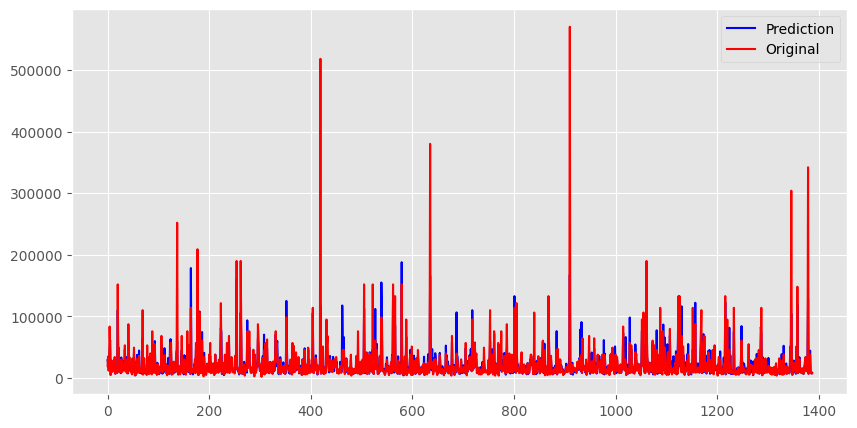

In [ ]:

plt.figure(figsize=(10, 5))
ax = plt.subplot()
ax.plot(df_result['pred'], color='b', label='Prediction')
ax.plot(df_result['true'], color='r', label='Original')
plt.legend()
plt.show()

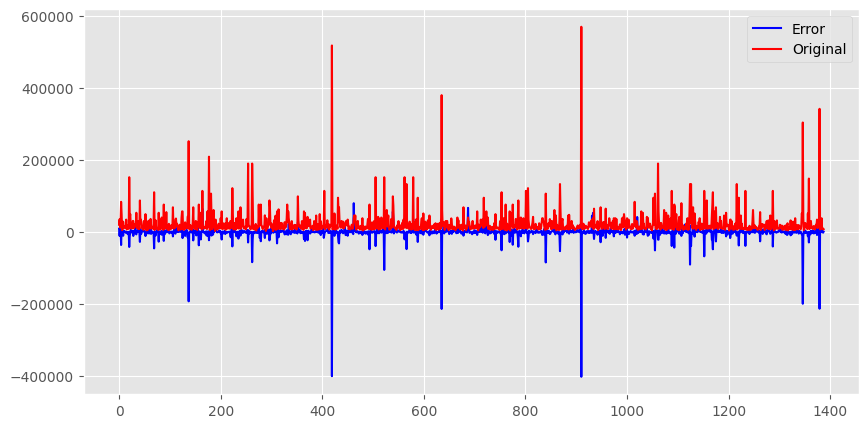

In [ ]:
plt.figure(figsize=(10, 5))
ax = plt.subplot()
ax.plot(df_result['diff'], 'b', label='Error')
ax.plot(df_result['true'], 'r', label='Original')
plt.legend()
plt.show()

### Prediction intervals with MAPIE

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5549, 51), (5549,), (1388, 51), (1388,))

In [ ]:
from mapie.quantile_regression import MapieQuantileRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=24,
                                                        stratify=X['rooms'])
parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.01,
    "n_estimators": 4730,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 30,
    'objective': 'quantile',
    'alpha': 0.05
}

regressor = lgb.LGBMRegressor(**parameters)
model = regressor.fit(X_train, y_train)

mapie = MapieQuantileRegressor(estimator=model, cv='split')
mapie.fit(X_train, y_train)

y_pred_mapie, y_pis = mapie.predict(X_test)

predictions = y_test.to_frame()
predictions.columns = ['y_true']
predictions["point prediction"] = y_pred_mapie
predictions["lower"] = y_pis.reshape(-1,2)[:,0]
predictions["upper"] = y_pis.reshape(-1,2)[:,1]
# take a quick look
predictions

d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\mapie\utils.py:484: UserWarning: WARNING: The predictions of the quantile regression have issues.
The upper quantile predictions are lower
than the lower quantile predictions
at some points.
  warnings.warn(
d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\mapie\utils.py:502: UserWarning: WARNING: The predictions have issues.
The upper predictions are lower thanthe lower predictions at some points.
  warnings.warn(


,y_true,point prediction,lower,upper
6374,20000,28490.974077,16400.794972,49625.625153
3354,35000,23438.998290,14288.976932,49197.746942
1239,12000,18188.099507,11411.482556,31128.305156
1600,26000,32007.154344,18539.045376,45143.237327
3672,83562,45005.071735,23729.951404,81418.062949
...,...,...,...,...
704,38000,48370.906312,27032.204489,91378.129626
759,8000,9892.959775,7317.465388,13417.165772
3328,9000,8512.374745,5645.986165,12308.389409
4401,9500,8727.293156,5952.682212,11871.755998


In [ ]:
parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    'metric': 'custom',
}

model = lgb.LGBMRegressor(**parameters)
model.fit(X, y)

y_pred = model.predict(X)

def likelihood_obj(log_var: np.ndarray, data: lgb.Dataset):
    y_true = data.get_label()
    grad = 1 - (y_pred - y_true) ** 2 / np.exp(log_var)
    hess = (y_pred - y_true) ** 2 * np.exp(-1 * log_var)
    return grad, hess

variance_estimator = lgb.train(
    parameters,
    lgb.Dataset(X, y),
    num_boost_round=805,
    fobj=likelihood_obj,
)

log_var_pred = variance_estimator.predict(X)
std_pred = np.sqrt(np.exp(log_var_pred))

df = pd.DataFrame({
    "y": y,
    "pred": y_pred,
    "lower*1": y_pred - std_pred * 1,
    "upper*1": y_pred + std_pred * 1,

    # "upper*2": y_pred + std_pred * 2,
    # "lower*2": y_pred - std_pred * 2,
    # "upper*3": y_pred + std_pred * 3,
    # "lower*3": y_pred - std_pred * 3,
})

df

d:\Мои Документы\Nata\DS\ml_course_work\env\lib\site-packages\lightgbm\engine.py:177: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] Using self-defined objective function
[LightGBM] [Info] Total Bins 1899
[LightGBM] [Info] Number of data points in the train set: 6937, number of used features: 49
[LightGBM] [Warning] Using self-defined objective function


,y,pred,lower*1,upper*1
0,8499,11166.338372,8897.267298,13435.409446
1,37962,19941.072612,11406.663302,28475.481922
2,38000,39222.215502,29891.940187,48552.490817
3,23000,31142.387839,20369.287141,41915.488537
4,14000,13847.566647,11390.160981,16304.972312
...,...,...,...,...
6932,9200,7084.363774,4777.087517,9391.640031
6933,41800,54058.753395,32467.291123,75650.215666
6934,38000,34949.328680,23761.137869,46137.519491
6935,9500,8544.661740,7135.325201,9953.998279


In [ ]:
print(f"{y_test_pred[:5]}±{std}")

[34419.83899511 45497.07637341 19192.80335285 30563.79760791
 44785.56429984]±14134.447733690187


### Confidence interval for ensembling

In [ ]:
from mapie.regression import MapieRegressor

In [ ]:
def conf_interval(models):
    #res = []
    estimators = []
    predictions = y_test.to_frame()
    predictions.columns = ['y_true']
    for i, model in enumerate(models):
        model.fit(X_train, y_train)

        estimators.append(model)
        mapie_reg = MapieRegressor(estimator=model, cv=kf, agg_function='median')
        mapie_reg.fit(X_train, y_train)

        y_pred_mapie, y_pis = mapie_reg.predict(X_test, ensemble=True, alpha=0.3)

        predictions[f"point prediction_{i}"] = y_pred_mapie
        predictions[f"lower_{i}"] = y_pis.reshape(-1,2)[:,0]
        predictions[f"upper_{i}"] = y_pis.reshape(-1,2)[:,1]
    predictions['prediction'] = predictions.filter(regex='point').mean(axis=1)
    predictions['lower'] = predictions.filter(regex='lower').mean(axis=1)
    predictions['upper'] = predictions.filter(regex='upper').mean(axis=1)
    predictions['error_lower'] = predictions['prediction'] - predictions['lower']
    predictions['error_upper'] = predictions['upper'] - predictions['prediction']
    predictions['error'] = predictions.filter(regex='error').mean(axis=1)

    return predictions[['y_true', 'prediction', 'error']]

In [ ]:
parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

In [ ]:
parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.1,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
}

model_2 = xgb.XGBRegressor(**parameters_2)

In [ ]:
models = [model_1, model_2]
df_res = conf_interval(models)
df_res

,y_true,prediction,error
6374,20000,29141.360069,6420.885004
3354,35000,31177.102538,7779.044735
1239,12000,17894.931609,6464.276152
1600,26000,29085.572356,6315.540823
3672,83562,47641.912858,7377.801746
...,...,...,...
704,38000,50180.312285,7625.424112
759,8000,9478.265549,6231.446759
3328,9000,8370.155589,6200.758128
4401,9500,7884.632424,6245.473511


### Feature Interactions with xgbfir

In [ ]:
X_transform = transformer.fit_transform(X)

xgb_train = xgb.DMatrix(X_transform, y)

num_rounds = 1_000

parameters_xgb = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.1,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
}

results = xgb.cv(parameters_xgb, xgb_train, num_rounds,
                 folds=kf, early_stopping_rounds=10, verbose_eval=50)


[0]	train-rmsle:2.20578+0.00492	test-rmsle:2.20815+0.02374
[50]	train-rmsle:0.39389+0.00395	test-rmsle:0.40019+0.00694
[100]	train-rmsle:0.36168+0.00309	test-rmsle:0.37069+0.00780
[150]	train-rmsle:0.35161+0.00195	test-rmsle:0.36366+0.00779
[200]	train-rmsle:0.34545+0.00246	test-rmsle:0.36068+0.00779
[203]	train-rmsle:0.34530+0.00250	test-rmsle:0.36056+0.00779


In [ ]:
model = xgb.train(parameters_xgb, xgb_train, num_boost_round=205)
xgbfir.saveXgbFI(
    model,
    feature_names=transformer.get_feature_names_out().tolist(),
    OutputXlsxFile=pjoin("../data", "xgbfir_importance_new.xlsx")
)

In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fix_error_fe_log.csv')

data['full_area|kitchen_area_log'] = data['full_area'] / data['kitchen_area_log']

#data_te_fir['full_area_log|kitchen_area_log'] = data_te_fir['kitchen_area_log'] / data_te_fir['full_area_log']
#data_te_fir['dist_to_center|full_area'] = data_te_fir['dist_to_center'] * data_te_fir['full_area']
#data_te_fir['dist_to_center|kitchen_area'] = data_te_fir['dist_to_center'] * data_te_fir['kitchen_area']

num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2595, test_rmsle: 0.3004
[Fold 1] train_rmsle: 0.2633, test_rmsle: 0.2908
[Fold 2] train_rmsle: 0.2653, test_rmsle: 0.2754
[Fold 3] train_rmsle: 0.2636, test_rmsle: 0.2807
[Fold 4] train_rmsle: 0.2597, test_rmsle: 0.2932
RMSLE: 0.2881 ± 0.0090


RMSLE: 0.2894 ± 0.0089

In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fix_error_fe_log.csv')

data['full_area|kitchen_area_log'] = data['full_area'] / data['kitchen_area_log']
# data['designer_renovation|full_area'] = data['designer_renovation'] * data['full_area']
# data['dist_to_center|full_area'] = data['dist_to_center'] * data['full_area']
# data['kitchen_area|rooms'] = data['kitchen_area'] / data['rooms']
data['dist_to_center|full_area_log'] = data['dist_to_center'] / data['full_area_log']

#data_te_fir['full_area_log|kitchen_area_log'] = data_te_fir['kitchen_area_log'] / data_te_fir['full_area_log']

#data_te_fir['dist_to_center|kitchen_area'] = data_te_fir['dist_to_center'] * data_te_fir['kitchen_area']

num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2573, test_rmsle: 0.3001
[Fold 1] train_rmsle: 0.2628, test_rmsle: 0.2927
[Fold 2] train_rmsle: 0.2646, test_rmsle: 0.2747
[Fold 3] train_rmsle: 0.2638, test_rmsle: 0.2792
[Fold 4] train_rmsle: 0.2597, test_rmsle: 0.2933
RMSLE: 0.2880 ± 0.0095


RMSLE: 0.2881 ± 0.0090

In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fix_error_fe_log.csv')

data['full_area|kitchen_area_log'] = data['full_area'] / data['kitchen_area_log']
# data['designer_renovation|full_area'] = data['designer_renovation'] * data['full_area']
#data['dist_to_center|full_area'] = data['dist_to_center'] * data['full_area']
data['kitchen_area|rooms'] = data['kitchen_area'] / data['rooms']
# data['dist_to_center|full_area_log'] = data['dist_to_center'] * data['full_area_log']
data['full_area_log|kitchen_area'] = data['full_area_log'] / data['kitchen_area']

data['full_area|kitchen_area'] = data['kitchen_area'] * data['full_area']

data['full_area_log|kitchen_area_log'] = data['kitchen_area_log'] / data['full_area_log']

# data['dist_to_center|kitchen_area'] = data['dist_to_center'] / data['kitchen_area']

num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2572, test_rmsle: 0.3026
[Fold 1] train_rmsle: 0.2623, test_rmsle: 0.2925
[Fold 2] train_rmsle: 0.2633, test_rmsle: 0.2757
[Fold 3] train_rmsle: 0.2649, test_rmsle: 0.2794
[Fold 4] train_rmsle: 0.2588, test_rmsle: 0.2966
RMSLE: 0.2894 ± 0.0102


In [ ]:
data['needs_repairs'] = data['needs_cosmetic_repairs'] + data['needs_major_repairs']

In [ ]:
black_list = ['id', 'price', 'price_log', 'class',
              'residential', 'detail', 'description',
              'subway_old', 'needs_cosmetic_repairs',
              'needs_major_repairs']
num_feats = [col for col in data.columns if data[col].dtypes != 'object' and col not in black_list]
feats = num_feats + ['subway', 'district']

In [ ]:
X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2573, test_rmsle: 0.3001
[Fold 1] train_rmsle: 0.2628, test_rmsle: 0.2927
[Fold 2] train_rmsle: 0.2646, test_rmsle: 0.2747
[Fold 3] train_rmsle: 0.2638, test_rmsle: 0.2792
[Fold 4] train_rmsle: 0.2597, test_rmsle: 0.2933
RMSLE: 0.2880 ± 0.0095


In [ ]:
data.to_csv('../data/real_estate_geo_location_fix_error_fe_log_fir.csv', index=False)

In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fix_error_fe_log_fir.csv')

In [ ]:
data.columns

Index(['id', 'price', 'rooms', 'floor', 'adress', 'district', 'subway',
       'class', 'residential', 'description', 'detail', 'full_area',
       'living_area', 'kitchen_area', 'num_storeys', 'subway_old',
       'typical_panel', 'concrete_monolithic', 'old_brick', 'first_rental',
       'adjacent_separate', 'ukrainian_brick', 'eurorenovation',
       'satisfactory_condition', 'multilevel', 'needs_cosmetic_repairs',
       'kitchen_living_room', 'penthouse', 'old_panel', 'good_condition',
       'pre_revolutionary', 'needs_major_repairs', 'gas_block',
       'repair_in_progress', 'free_planning', 'adjacent', 'separate',
       'ukrainian_panel', 'Stalinka', 'excellent_condition', 'studio',
       'designer_renovation', 'safe', 'shower_cabin', 'wardrobe', 'TV',
       'hair_dryer', 'dishes', 'satellite_TV', 'DVD_player', 'washing_machine',
       'fireplace', 'dishwashers', 'alarms', 'bed', 'counters',
       'air_conditioning', 'refrigerator', 'jacuzzi', 'microwave', 'iron',
       '

In [ ]:
data['subway'].fillna('unknown', inplace=True)


In [ ]:
data.to_csv('../data/real_estate_geo_location_fe_log_fir_fillna_12.05.14.40.csv', index=False)

In [ ]:
X, y = get_X_y(data, feats)

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district']),
     ('labelEnc', OrdinalEncoder(), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    'metric': 'custom',
}
model = lgb.LGBMRegressor(**parameters)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

# lgb_train = lgb.Dataset(X, np.log1p(y),
#                         feature_name=num_feats,
#                         free_raw_data=False)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2595, test_rmsle: 0.3007
[Fold 1] train_rmsle: 0.2631, test_rmsle: 0.2934
[Fold 2] train_rmsle: 0.2653, test_rmsle: 0.2775
[Fold 3] train_rmsle: 0.2644, test_rmsle: 0.2821
[Fold 4] train_rmsle: 0.2625, test_rmsle: 0.2929
RMSLE: 0.2893 ± 0.0084


In [ ]:
black_list = ['id', 'price', 'class',
              'residential', 'detail', 'description',
              'subway_old', 'needs_cosmetic_repairs',
              'needs_major_repairs']
num_feats = [col for col in data.columns if data[col].dtypes != 'object' and col not in black_list]
feats = num_feats + ['subway', 'district']


In [ ]:
data['kitchen_area_log'] = np.log1p(data['kitchen_area'])

In [ ]:
data['kitchen_area_log'].describe()

count    6937.000000
mean        2.554359
std         0.510532
min         0.693147
25%         2.197225
50%         2.564949
75%         2.890372
max         5.081404
Name: kitchen_area_log, dtype: float64

In [ ]:
data['full_area|kitchen_area_log'] = data['full_area'] / data['kitchen_area_log']

In [ ]:
data['full_area_log'] = np.log1p(data['full_area'])

In [ ]:
data['full_area_log'].describe()

count    6937.000000
mean        4.128985
std         0.481329
min         2.772589
25%         3.828641
50%         4.043051
75%         4.394449
max         6.398595
Name: full_area_log, dtype: float64

In [ ]:
data['dist_to_center|full_area_log'] = data['dist_to_center'] / data['full_area_log']

In [ ]:
X, y = get_X_y(data, feats)

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")
X_transform = transformer.fit_transform(X)
X_transform


,district_Голосіївський,district_Дарницький,district_Деснянський,district_Дніпровський,district_Оболонський,district_Печерський,district_Подільський,district_Святошинський,district_Солом'янський,district_Шевченківський,...,dist_to_center,full_area_log,floor_other,num_storeys_other,living_area_log,kitchen_area_log,last_floor,first_floor,full_area|kitchen_area_log,dist_to_center|full_area_log
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.923706,4.912655,14,17,4.605170,3.258097,False,False,41.435236,1.002250
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.341385,4.615121,6,6,4.382027,2.397895,True,False,41.703239,0.290650
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,13.441357,3.637586,19,24,2.944439,2.197225,False,False,16.839426,3.695131
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.264119,3.610918,18,25,2.708050,2.564949,False,False,14.035365,1.457834
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,7.171231,3.970292,18,25,2.995732,2.564949,False,False,20.273305,1.806223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,10.513925,3.931826,9,25,2.995732,2.772589,False,False,18.033688,2.674057
6933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,10.100934,3.610918,8,9,2.995732,2.197225,False,False,16.384306,2.797332
6934,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,8.437642,3.496508,3,9,2.772589,2.079442,False,False,15.388747,2.413163
6935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,11.548596,3.828641,3,16,3.555348,2.302585,False,False,19.543252,3.016369


In [ ]:
lgb_train = lgb.Dataset(X_transform, np.log1p(y),
                        feature_name=transformer.get_feature_names_out().tolist(),
                        free_raw_data=False)

num_boost_round = 2000

def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.1,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 100,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(50)]
    )

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Training until validation scores don't improve for 10 rounds
[50]	cv_agg's train rmsle: 0.329934 + 0.00209652	cv_agg's valid rmsle: 0.334175 + 0.00990388
[100]	cv_agg's train rmsle: 0.309519 + 0.00194263	cv_agg's valid rmsle: 0.315882 + 0.00858152
[150]	cv_agg's train rmsle: 0.300482 + 0.00187763	cv_agg's valid rmsle: 0.308499 + 0.00767799
[200]	cv_agg's train rmsle: 0.293974 + 0.0015426	cv_agg's valid rmsle: 0.303543 + 0.00726234
[250]	cv_agg's train rmsle: 0.28919 + 0.00168882	cv_agg's valid rmsle: 0.299898 + 0.00686542
[300]	cv_agg's train rmsle: 0.285431 + 0.00156736	cv_agg's valid rmsle: 0.297425 + 0.00680471
[350]	cv_agg's train rmsle: 0.282441 + 0.00163312	cv_agg's valid rmsle: 0.296106 + 0.00673652
[400]	cv_agg's train rmsle: 0.279667 + 0.00171651	cv_agg's valid rmsle: 0.294792 + 0.00691428
Early stopping, best iteration is:
[398]	cv_agg's train rmsle: 0.279746 + 0.00170017	cv_agg's valid rmsle: 0.2

In [ ]:
X_transform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6937 entries, 0 to 6936
Columns: 129 entries, district_Голосіївський to needs_repairs
dtypes: bool(2), float64(77), int64(50)
memory usage: 6.7 MB


In [ ]:
X_transform.columns.to_series()[np.isinf(X_transform).any()]

Series([], dtype: object)

In [ ]:
xgb_train = xgb.DMatrix(X_transform, np.log1p(y))

num_rounds = 1_000

parameters_xgb = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.1,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
}

model = xgb.train(parameters_xgb, xgb_train, num_boost_round=205)
xgbfir.saveXgbFI(
    model,
    feature_names=transformer.get_feature_names_out().tolist(),
    OutputXlsxFile=pjoin("../data", "xgbfir_importance_new_log.xlsx")
)

In [ ]:
data.to_csv('../data/real_estate_geo_location_fe_log1p_fir_fillna_12.05.16.20.csv', index=False)

In [ ]:
num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2622, test_rmsle: 0.3020
[Fold 1] train_rmsle: 0.2651, test_rmsle: 0.2939
[Fold 2] train_rmsle: 0.2669, test_rmsle: 0.2769
[Fold 3] train_rmsle: 0.2664, test_rmsle: 0.2855
[Fold 4] train_rmsle: 0.2638, test_rmsle: 0.2952
RMSLE: 0.2907 ± 0.0087


In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district', 'subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    'metric': 'custom',
}
model = lgb.LGBMRegressor(**parameters)


pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fe_log1p_fir_fillna_12.05.16.20.csv')

data['dist_to_center|full_area_log|kitchen_area'] = data['dist_to_center'] * data['full_area'] * data['kitchen_area']

num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2622, test_rmsle: 0.3020
[Fold 1] train_rmsle: 0.2651, test_rmsle: 0.2939
[Fold 2] train_rmsle: 0.2669, test_rmsle: 0.2769
[Fold 3] train_rmsle: 0.2664, test_rmsle: 0.2855
[Fold 4] train_rmsle: 0.2638, test_rmsle: 0.2952
RMSLE: 0.2907 ± 0.0087


In [ ]:
data = pd.read_csv('../data/real_estate_geo_location_fe_log1p_fir_fillna_12.05.16.20.csv')

data['dist_to_center|full_area_log|kitchen_area'] = data['dist_to_center'] * data['full_area'] * data['kitchen_area']
#data['dist_to_center|full_area_log|living_area_log'] = data['dist_to_center'] * data['full_area'] * data['kitchen_area'] / data['living_area_log']

# data['full_area|kitchen_area'] = data['full_area'] - data['kitchen_area']

#data['full_area|kitchen_area_log'] = data['full_area'] / data['kitchen_area_log']
# data['designer_renovation|full_area'] = data['designer_renovation'] * data['full_area']

#data['kitchen_area|rooms'] = data['kitchen_area'] / data['rooms']
## data['dist_to_center|full_area_log'] = data['dist_to_center'] * data['full_area_log']
#data['full_area_log|kitchen_area'] = data['full_area_log'] / data['kitchen_area']



#data['full_area_log|kitchen_area_log'] = data['kitchen_area_log'] / data['full_area_log']

# data['dist_to_center|kitchen_area'] = data['dist_to_center'] / data['kitchen_area']

num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list]
feats = num_feats + ['subway', 'district']

X, y = get_X_y(data, feats)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2597, test_rmsle: 0.3014
[Fold 1] train_rmsle: 0.2609, test_rmsle: 0.2917
[Fold 2] train_rmsle: 0.2639, test_rmsle: 0.2794
[Fold 3] train_rmsle: 0.2635, test_rmsle: 0.2827
[Fold 4] train_rmsle: 0.2600, test_rmsle: 0.2947
RMSLE: 0.2900 ± 0.0080


In [ ]:
data.to_csv('../data/real_estate_geo_location_fe_log1p_fir_fillna_12.05.16.20.csv', index=False)


### Ensembling techniques

In [ ]:
df = pd.read_csv('../data/real_estate_clean.csv')
df.columns

Index(['id', 'price', 'rooms', 'floor', 'adress', 'district', 'subway',
       'class', 'residential', 'description', 'detail', 'full_area',
       'living_area', 'kitchen_area', 'num_storeys', 'subway_old',
       'typical_panel', 'concrete_monolithic', 'old_brick', 'first_rental',
       'adjacent_separate', 'ukrainian_brick', 'eurorenovation',
       'satisfactory_condition', 'multilevel', 'needs_cosmetic_repairs',
       'kitchen_living_room', 'penthouse', 'old_panel', 'good_condition',
       'pre_revolutionary', 'needs_major_repairs', 'gas_block',
       'repair_in_progress', 'free_planning', 'adjacent', 'separate',
       'ukrainian_panel', 'Stalinka', 'excellent_condition', 'studio',
       'designer_renovation', 'safe', 'shower_cabin', 'wardrobe', 'TV',
       'hair_dryer', 'dishes', 'satellite_TV', 'DVD_player', 'washing_machine',
       'fireplace', 'dishwashers', 'alarms', 'bed', 'counters',
       'air_conditioning', 'refrigerator', 'jacuzzi', 'microwave', 'iron',
       '

In [ ]:
df['needs_repairs'] = df['needs_cosmetic_repairs'] + df['needs_major_repairs']


In [ ]:
data = data.merge(df[['id', 'needs_repairs']], how='left', on='id')
data.columns

Index(['id', 'price', 'rooms', 'floor', 'full_area', 'living_area',
       'kitchen_area', 'num_storeys', 'typical_panel', 'concrete_monolithic',
       'old_brick', 'first_rental', 'adjacent_separate', 'ukrainian_brick',
       'eurorenovation', 'satisfactory_condition', 'multilevel',
       'kitchen_living_room', 'penthouse', 'old_panel', 'good_condition',
       'pre_revolutionary', 'gas_block', 'repair_in_progress', 'free_planning',
       'adjacent', 'separate', 'ukrainian_panel', 'Stalinka',
       'excellent_condition', 'studio', 'designer_renovation', 'safe',
       'shower_cabin', 'wardrobe', 'TV', 'hair_dryer', 'dishes',
       'satellite_TV', 'DVD_player', 'washing_machine', 'fireplace',
       'dishwashers', 'alarms', 'bed', 'counters', 'air_conditioning',
       'refrigerator', 'jacuzzi', 'microwave', 'iron', 'cable_TV', 'lat',
       'lon', 'district_lat', 'district_lon', 'min_dist_to_subway',
       'dist_to_center', 'full_area_log', 'floor_other', 'num_storeys_other',
 

In [ ]:
data.to_csv('../data/real_estate_last.csv', index=False)

In [ ]:
black_list = ['id', 'price', 'class', 'residential', 'detail', 'description', 'subway_old']
num_feats = [col for col in data.columns if data[col].dtypes != 'object' and col not in black_list]
feats = num_feats + ['subway', 'district']

In [ ]:
#del_without_log_feats = ['full_area_log', 'living_area_log', 'kitchen_area_log', 'floor', 'num_storeys']
#feats = [x for x in num_feats if x not in del_without_log_feats]

In [ ]:
X, y = get_X_y(data, feats)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=24,
                                                    stratify=X['rooms'])

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district']),
     ('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1, unknown_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('OneHot',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['district']),
                                ('labelEnc',
                                 OrdinalEncoder(encoded_missing_value=-1,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['subway'])],
                  verbose_feature_names_out=False)

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['district']),
     ('labelEnc', OrdinalEncoder(encoded_missing_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")

parameters = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    'metric': 'custom',
}
model = lgb.LGBMRegressor(**parameters)

pipeline = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

# lgb_train = lgb.Dataset(X, np.log1p(y),
#                         feature_name=num_feats,
#                         free_raw_data=False)

run_cv(pipeline, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2595, test_rmsle: 0.3007
[Fold 1] train_rmsle: 0.2631, test_rmsle: 0.2934
[Fold 2] train_rmsle: 0.2653, test_rmsle: 0.2775
[Fold 3] train_rmsle: 0.2644, test_rmsle: 0.2821
[Fold 4] train_rmsle: 0.2625, test_rmsle: 0.2929
RMSLE: 0.2893 ± 0.0084


In [ ]:
parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

pipeline_lgb = Pipeline([
    ('transform', transformer),
    ('regr', model_1)
])

In [ ]:
parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.3,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    'n_estimators': 1000

}

model_2 = xgb.XGBRegressor(**parameters_2)

pipeline_xgb = Pipeline([
    ('transform', transformer),
    ('regr', model_2)
])

In [ ]:
parameters_3 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.3,
    "n_estimators": 1000,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 150,
    'objective': 'regression',
    'metric': 'custom',
}

model_3 = lgb.LGBMRegressor(**parameters_3)

pipeline_lgb_3 = Pipeline([
    ('transform', transformer),
    ('regr', model_3)
])

run_cv(pipeline_lgb_3, X, y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2368, test_rmsle: 0.2990
[Fold 1] train_rmsle: 0.2389, test_rmsle: 0.2892
[Fold 2] train_rmsle: 0.2398, test_rmsle: 0.2780
[Fold 3] train_rmsle: 0.2392, test_rmsle: 0.2831
[Fold 4] train_rmsle: 0.2392, test_rmsle: 0.2923
RMSLE: 0.2883 ± 0.0073


In [ ]:
lgb_predictions = []
xgb_predictions = []

for train, val in skf.split(X, X['rooms']):
    pipeline_lgb.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_xgb.fit(X.iloc[train], np.log1p(y[train]))
    lgb_predictions.append([y[val], np.expm1(pipeline_lgb.predict(X.iloc[val]))])
    xgb_predictions.append([y[val], np.expm1(pipeline_xgb.predict(X.iloc[val]))])

In [ ]:
np.mean([rmsle_score(i[0], i[1]) for i in lgb_predictions]), np.mean([rmsle_score(i[0], i[1]) for i in xgb_predictions])

(0.28931890112851333, 0.28495777125198185)

In [ ]:
np.mean([rmsle_score(lgb_p[0], lgb_p[1]*0.5 + xgb_p[1]*0.5) for lgb_p, xgb_p in zip(lgb_predictions, xgb_predictions)])

0.28050333529689697

In [ ]:
np.mean([rmsle_score(lgb_p[0], np.sqrt(lgb_p[1] * xgb_p[1])) for lgb_p, xgb_p in zip(lgb_predictions, xgb_predictions)])

0.2806573063377322

In [ ]:
np.mean([rmsle_score(lgb_p[0], lgb_p[1]*0.4+ xgb_p[1]*0.6) for lgb_p, xgb_p in zip(lgb_predictions, xgb_predictions)])

0.2803402717164162

def ensembling_models(models):
    model_pred = []
    for model in models:
        name_pred = f"{model}_predictions"
        name_pred = []
    
        for train, val in skf.split(X, X['rooms']):
            model.fit(X.iloc[train], np.log1p(y[train]))
            name_pred.append([y[val], np.expm1(model.predict(X.iloc[val]))])
    
        print(np.mean([rmsle_score(i[0], i[1]) for i in name_pred]))

    model_pred.append(name_pred)
    
    return model_pred
    # np.mean([rmsle_score(lgb_p[0], lgb_p[1]*0.5 + xgb_p[1]*0.5) for lgb_p, xgb_p in zip(lgb_predictions, xgb_predictions)])

In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_lgb.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_xgb.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_lgb_3.fit(X.iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_lgb.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_xgb.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_lgb_3.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    )

(0.28931890112851333, 0.28495777125198185, 0.2887370807905869)

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.34 + p_2[1]*0.33 + p_3[1]*0.33) for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.279611223591692

In [ ]:
np.mean(
    [rmsle_score(p_1[0], (p_1[1]*p_2[1]*p_3[1])**(1./3))
        for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.2797373696705005

In [ ]:
np.mean(
    [rmsle_score(p_1[0], np.median((p_1[1], p_2[1], p_3[1]), axis=0))
        for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.2822203271229286

In [ ]:
parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

pipeline_1 = Pipeline([
    ('transform', transformer),
    ('regr', model_1)
])

In [ ]:
parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.3,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    'n_estimators': 1000

}

model_2 = xgb.XGBRegressor(**parameters_2)

pipeline_2 = Pipeline([
    ('transform', transformer),
    ('regr', model_2)
])

In [ ]:
parameters_ctb = {
    #"loss_function": "Logloss",
    #"eval_metric": "rms",
    "iterations": 1000,
    "learning_rate": 0.1,
    "random_seed": 24,
    "od_wait": 30,
    "od_type": "Iter",
    "thread_count": 4,
    "verbose": False
}

model_4 = ctb.CatBoostRegressor(**parameters_ctb)

pipeline_3 = Pipeline([
    ('transform', transformer),
    ('regr', model_4)
])


In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_1.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_2.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_3.fit(X.iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_1.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_2.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_3.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    )

(0.28931890112851333, 0.28495777125198185, 0.26905106991954375)

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.34 + p_2[1]*0.33 + p_3[1]*0.33) for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.2726865348315053

In [ ]:
np.mean(
    [rmsle_score(p_1[0], (p_1[1]*p_2[1]*p_3[1])**(1./3))
        for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.2727094613914164

In [ ]:
np.mean(
    [rmsle_score(p_1[0], np.median((p_1[1], p_2[1], p_3[1]), axis=0))
        for p_1, p_2, p_3 in zip(predictions_1, predictions_2, predictions_3)]
    )

0.27387953665154646

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model_5 = ExtraTreesRegressor(
    max_depth=10, max_features=0.6,
    bootstrap=True,
    random_state=24, max_samples=0.8)

pipeline_5 = Pipeline([
    ('transform', transformer),
    ('regr', model_5)
])

transformer.set_output(transform='pandas')

run_cv(pipeline_5, X.fillna('unknown'), y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.2248, test_rmsle: 0.3075
[Fold 1] train_rmsle: 0.2261, test_rmsle: 0.3075
[Fold 2] train_rmsle: 0.2277, test_rmsle: 0.2878
[Fold 3] train_rmsle: 0.2263, test_rmsle: 0.2896
[Fold 4] train_rmsle: 0.2257, test_rmsle: 0.3045
RMSLE: 0.2994 ± 0.0088


In [ ]:
model_5 = ExtraTreesRegressor(
    max_depth=10, max_features=0.6,
    bootstrap=True,
    random_state=24, max_samples=0.8)

pipeline_4 = Pipeline([
    ('transform', transformer),
    ('regr', model_5)
])

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district']),
     ('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1, unknown_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('OneHot', OneHotEncoder(sparse_output=False),
                                 ['district']),
                                ('labelEnc',
                                 OrdinalEncoder(encoded_missing_value=-1,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['subway'])],
                  verbose_feature_names_out=False)

In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []
predictions_4 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_1.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_2.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_3.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_4.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_1.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_2.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_3.predict(X.iloc[val]))])
    predictions_4.append([y[val], np.expm1(pipeline_4.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_4]),
    )

(0.2906409878532493,
 0.2876324936433311,
 0.2698980997096439,
 0.30026497485776027)

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.23 + p_2[1]*0.27 + p_3[1]*0.3 + p_4[1]*0.2)
     for p_1, p_2, p_3, p_4 in zip(predictions_1, predictions_2, predictions_3, predictions_4)]
    )

0.27359056799655856

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.25 + p_2[1]*0.25 + p_3[1]*0.25 + p_4[1]*0.25)
     for p_1, p_2, p_3, p_4 in zip(predictions_1, predictions_2, predictions_3, predictions_4)]
    )

0.2747529754156843

In [ ]:
np.mean(
    [rmsle_score(p_1[0], (p_1[1]*p_2[1]*p_3[1]*p_4[1])**(1./4))
     for p_1, p_2, p_3, p_4 in zip(predictions_1, predictions_2, predictions_3, predictions_4)]
    )

0.2749663379519091

In [ ]:
model_6 = LinearRegression()

pipeline_4 = Pipeline([
    ('transform', transformer),
    ('regr', model_6)
])

transformer.set_output(transform='pandas')

run_cv(pipeline_4, X.fillna('unknown'), y, folds=5, target_log=True,
       cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.3040, test_rmsle: 0.3227
[Fold 1] train_rmsle: 0.3057, test_rmsle: 0.3167
[Fold 2] train_rmsle: 0.3098, test_rmsle: 0.2992
[Fold 3] train_rmsle: 0.3088, test_rmsle: 0.3033
[Fold 4] train_rmsle: 0.3051, test_rmsle: 0.3185
RMSLE: 0.3121 ± 0.0092


In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []
predictions_4 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_1.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_2.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_3.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_4.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_1.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_2.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_3.predict(X.iloc[val]))])
    predictions_4.append([y[val], np.expm1(pipeline_4.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_4]),
    )

(0.2906409878532493,
 0.2876324936433311,
 0.2698980997096439,
 0.3120873271131016)

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.23 + p_2[1]*0.27 + p_3[1]*0.35 + p_4[1]*0.15)
     for p_1, p_2, p_3, p_4 in zip(predictions_1, predictions_2, predictions_3, predictions_4)]
    )

0.27328890324673594

In [ ]:
np.mean(
    [rmsle_score(p_1[0], p_1[1]*0.2 + p_2[1]*0.3 + p_3[1]*0.4 + p_4[1]*0.1)
     for p_1, p_2, p_3, p_4 in zip(predictions_1, predictions_2, predictions_3, predictions_4)]
    )

0.27231894966501147

In [ ]:
parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

pipeline_1 = Pipeline([
    ('transform', transformer),
    ('regr', model_1)
])


parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.3,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    'n_estimators': 1000

}

model_2 = xgb.XGBRegressor(**parameters_2)

pipeline_2 = Pipeline([
    ('transform', transformer),
    ('regr', model_2)
])


parameters_ctb = {
    #"loss_function": "Logloss",
    #"eval_metric": "rms",
    "iterations": 1000,
    "learning_rate": 0.1,
    "random_seed": 24,
    "od_wait": 30,
    "od_type": "Iter",
    "thread_count": 4,
    "verbose": False
}

model_3 = ctb.CatBoostRegressor(**parameters_ctb)

pipeline_3 = Pipeline([
    ('transform', transformer),
    ('regr', model_3)
])


model_4 = LinearRegression()

pipeline_4 = Pipeline([
    ('transform', transformer),
    ('regr', model_4)
])


model_5 = ExtraTreesRegressor(
    max_depth=10, max_features=0.6,
    bootstrap=True,
    random_state=24, max_samples=0.8)

pipeline_5 = Pipeline([
    ('transform', transformer),
    ('regr', model_5)
])

In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []
predictions_4 = []
predictions_5 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_1.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_2.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_3.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_4.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    pipeline_5.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_1.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_2.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_3.predict(X.iloc[val]))])
    predictions_4.append([y[val], np.expm1(pipeline_4.predict(X.iloc[val]))])
    predictions_5.append([y[val], np.expm1(pipeline_5.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_4]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_5]),
    )

(0.2906409878532493,
 0.2876324936433311,
 0.2698980997096439,
 0.3120873271131016,
 0.30026497485776027)

In [ ]:
np.mean(
    [rmsle_score(p_1[0],
                 p_1[1]*0.2 + p_2[1]*0.2 + p_3[1]*0.4 + p_4[1]*0.05 + p_5[1]*0.15)
     for p_1, p_2, p_3, p_4, p_5 in zip(predictions_1, predictions_2,
                                   predictions_3, predictions_4,
                                   predictions_5)]
    )

0.27196467946291286

In [ ]:
np.mean(
    [rmsle_score(p_1[0],
                 p_1[1]*0.2 + p_2[1]*0.25 + p_3[1]*0.4 + p_5[1]*0.15)
     for p_1, p_2, p_3, p_5 in zip(predictions_1, predictions_2,
                                   predictions_3,
                                   predictions_5)]
    )

0.2719639926615077

In [ ]:
np.mean(
    [rmsle_score(p_1[0],
                 p_1[1]*0.15 + p_2[1]*0.25 + p_3[1]*0.4 + p_4[1]*0.05 + p_5[1]*0.15)
     for p_1, p_2, p_3, p_4, p_5 in zip(predictions_1, predictions_2,
                                   predictions_3, predictions_4,
                                   predictions_5)]
    )

0.27174447511609373

In [ ]:
np.mean(
    [rmsle_score(p_1[0],
                 p_1[1]*0.1 + p_2[1]*0.3 + p_3[1]*0.4 + p_4[1]*0.05 + p_5[1]*0.15)
     for p_1, p_2, p_3, p_4, p_5 in zip(predictions_1, predictions_2,
                                   predictions_3, predictions_4,
                                   predictions_5)]
    )

0.27166195349732336

In [ ]:
data.to_csv('../data/real_estate_last.csv', index=False)

In [ ]:
data[['id', 'price'] + feats].to_csv('../data/real_estate_last.csv', index=False)

In [ ]:
df_last = pd.read_csv('../data/real_estate_last.csv')
df_last

,id,price,rooms,floor,full_area,living_area,kitchen_area,num_storeys,typical_panel,concrete_monolithic,...,num_storeys_other,living_area_log,kitchen_area_log,last_floor,first_floor,full_area|kitchen_area_log,dist_to_center|full_area_log,dist_to_center|full_area_log|kitchen_area,subway,district
0,10825753,133000,4,14,135.0,100.0,25.0,17,0,0,...,17,4.605170,3.258097,False,False,41.435236,1.002250,16617.507827,дружби народів,Печерський
1,10784117,22762,3,6,100.0,80.0,10.0,6,0,0,...,6,4.382027,2.397895,True,False,41.703239,0.290650,1341.384685,хрещатик,Печерський
2,10810186,8499,1,19,37.0,19.0,8.0,24,0,0,...,24,2.944439,2.197225,False,False,16.839426,3.695131,3978.641593,академмістечко,Святошинський
3,10824293,10500,1,18,36.0,15.0,12.0,25,0,1,...,25,2.708050,2.564949,False,False,14.035365,1.457834,2274.099316,лівобережна,Дніпровський
4,10819688,37962,2,18,52.0,20.0,12.0,25,0,0,...,25,2.995732,2.564949,False,False,20.273305,1.806223,4474.848099,мінська,Оболонський
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6932,10620878,16000,1,9,50.0,20.0,15.0,25,0,1,...,25,2.995732,2.772589,False,False,18.033688,2.674057,7885.443759,житомирська,Святошинський
6933,10803998,9500,1,8,36.0,20.0,8.0,9,0,0,...,9,2.995732,2.197225,False,False,16.384306,2.797332,2909.069127,святошин,Святошинський
6934,9615917,6000,2,3,32.0,16.0,7.0,9,0,0,...,9,2.772589,2.079442,False,False,15.388747,2.413163,1890.031791,святошин,Шевченківський
6935,10055853,9000,1,3,45.0,35.0,9.0,16,1,0,...,16,3.555348,2.302585,False,False,19.543252,3.016369,4677.181378,NaN,Святошинський


In [ ]:
feats

['rooms',
 'floor',
 'full_area',
 'living_area',
 'kitchen_area',
 'num_storeys',
 'typical_panel',
 'concrete_monolithic',
 'old_brick',
 'first_rental',
 'adjacent_separate',
 'ukrainian_brick',
 'eurorenovation',
 'satisfactory_condition',
 'multilevel',
 'kitchen_living_room',
 'penthouse',
 'old_panel',
 'good_condition',
 'pre_revolutionary',
 'gas_block',
 'repair_in_progress',
 'free_planning',
 'adjacent',
 'separate',
 'ukrainian_panel',
 'Stalinka',
 'excellent_condition',
 'studio',
 'designer_renovation',
 'safe',
 'shower_cabin',
 'wardrobe',
 'TV',
 'hair_dryer',
 'dishes',
 'satellite_TV',
 'DVD_player',
 'washing_machine',
 'fireplace',
 'dishwashers',
 'alarms',
 'bed',
 'counters',
 'air_conditioning',
 'refrigerator',
 'jacuzzi',
 'microwave',
 'iron',
 'cable_TV',
 'lat',
 'lon',
 'district_lat',
 'district_lon',
 'min_dist_to_subway',
 'dist_to_center',
 'full_area_log',
 'floor_other',
 'num_storeys_other',
 'living_area_log',
 'kitchen_area_log',
 'last_floor',

In [ ]:
black_list = ['id', 'price', 'price_log', 'class',
              'residential', 'detail', 'description',
              'subway_old', 'needs_cosmetic_repairs',
              'needs_major_repairs']
num_feats = [col for col in data.columns if data[col].dtypes != 'object'
             and col not in black_list
             and col not in black_list]
feats = num_feats + ['subway', 'district']

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district']),
     ('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1, unknown_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")

In [ ]:
X, y = get_X_y(data, feats)

parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

pipeline_1 = Pipeline([
    ('transform', transformer),
    ('regr', model_1)
])


parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.3,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    'n_estimators': 1000

}

model_2 = xgb.XGBRegressor(**parameters_2)

pipeline_2 = Pipeline([
    ('transform', transformer),
    ('regr', model_2)
])


parameters_ctb = {
    #"loss_function": "Logloss",
    #"eval_metric": "rms",
    "iterations": 1000,
    "learning_rate": 0.1,
    "random_seed": 24,
    "od_wait": 30,
    "od_type": "Iter",
    "thread_count": 4,
    "verbose": False
}

model_3 = ctb.CatBoostRegressor(**parameters_ctb)

pipeline_3 = Pipeline([
    ('transform', transformer),
    ('regr', model_3)
])


model_4 = LinearRegression()

pipeline_4 = Pipeline([
    ('transform', transformer),
    ('regr', model_4)
])


model_5 = ExtraTreesRegressor(
    max_depth=10, max_features=0.6,
    bootstrap=True,
    random_state=24, max_samples=0.8)

pipeline_5 = Pipeline([
    ('transform', transformer),
    ('regr', model_5)
])

In [ ]:
predictions_1 = []
predictions_2 = []
predictions_3 = []
predictions_4 = []
predictions_5 = []

for train, val in skf.split(X, X['rooms']):
    pipeline_1.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_2.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_3.fit(X.iloc[train], np.log1p(y[train]))
    pipeline_4.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    pipeline_5.fit(X.fillna('unknown').iloc[train], np.log1p(y[train]))
    predictions_1.append([y[val], np.expm1(pipeline_1.predict(X.iloc[val]))])
    predictions_2.append([y[val], np.expm1(pipeline_2.predict(X.iloc[val]))])
    predictions_3.append([y[val], np.expm1(pipeline_3.predict(X.iloc[val]))])
    predictions_4.append([y[val], np.expm1(pipeline_4.predict(X.iloc[val]))])
    predictions_5.append([y[val], np.expm1(pipeline_5.predict(X.iloc[val]))])

In [ ]:
(
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_1]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_2]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_3]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_4]),
    np.mean([rmsle_score(i[0], i[1]) for i in predictions_5]),
    )

(0.2906409878532493,
 0.29002992521799076,
 0.2710139893548609,
 0.3120438939638127,
 0.298838779272546)

In [ ]:
np.mean(
    [rmsle_score(p_1[0],
                 p_1[1]*0.1 + p_2[1]*0.3 + p_3[1]*0.4 + p_4[1]*0.05 + p_5[1]*0.15)
     for p_1, p_2, p_3, p_4, p_5 in zip(predictions_1, predictions_2,
                                   predictions_3, predictions_4,
                                   predictions_5)]
    )

0.27267713133027094

In [ ]:
transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=False), ['district']),
     ('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1, unknown_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

transformer.set_output(transform="pandas")
X_transform = transformer.fit_transform(X)
X_transform

,district_Голосіївський,district_Дарницький,district_Деснянський,district_Дніпровський,district_Оболонський,district_Печерський,district_Подільський,district_Святошинський,district_Солом'янський,district_Шевченківський,...,full_area_log,floor_other,num_storeys_other,living_area_log,kitchen_area_log,last_floor,first_floor,full_area|kitchen_area_log,dist_to_center|full_area_log,dist_to_center|full_area_log|kitchen_area
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.912655,14,17,4.605170,3.258097,False,False,41.435236,1.002250,16617.507827
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.615121,6,6,4.382027,2.397895,True,False,41.703239,0.290650,1341.384685
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.637586,19,24,2.944439,2.197225,False,False,16.839426,3.695131,3978.641593
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.610918,18,25,2.708050,2.564949,False,False,14.035365,1.457834,2274.099316
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.970292,18,25,2.995732,2.564949,False,False,20.273305,1.806223,4474.848099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.931826,9,25,2.995732,2.772589,False,False,18.033688,2.674057,7885.443759
6933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.610918,8,9,2.995732,2.197225,False,False,16.384306,2.797332,2909.069127
6934,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.496508,3,9,2.772589,2.079442,False,False,15.388747,2.413163,1890.031791
6935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.828641,3,16,3.555348,2.302585,False,False,19.543252,3.016369,4677.181378


In [ ]:
parameters_1 = {
    "num_leaves": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 805,
    "subsample": 0.6,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "random_state": 24,
    "force_col_wise": True,
    'min_child_samples': 100,
    'objective': 'regression',
    #'metric': 'custom',
}

model_1 = lgb.LGBMRegressor(**parameters_1)

In [ ]:
feats_to_drop = ['full_area_log',
                 'num_storeys_other', 'floor_other', 'first_floor']

In [ ]:
parameters_2 = {
    "objective": "reg:squarederror",
    "eval_metric": "rmsle",
    "eta": 0.3,
    "verbosity": 1,
    "seed": 24,
    "tree_method": "hist",
    "grow_policy": "lossguide",

    # regularization parameters
    "max_depth": 5,
    "max_leaves": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    'n_estimators': 1000

}

model_2 = xgb.XGBRegressor(**parameters_2)

model = model_2.fit(X_transform, np.log1p(y))
show_weights(model, top=100)

Weight,Feature
0.1516,designer_renovation
0.0931,kitchen_area_log
0.0834,kitchen_area
0.0789,good_condition
0.0707,dist_to_center|full_area_log
0.0631,satisfactory_condition
0.0467,full_area
0.0405,district_Деснянський
0.0253,district_Печерський
0.0215,district_Солом'янський


In [ ]:
model = model_1.fit(X_transform, np.log1p(y))
show_weights(model, top=100)

Weight,Feature
0.2126,kitchen_area
0.2094,dist_to_center|full_area_log
0.1540,full_area
0.0763,designer_renovation
0.0641,full_area_log
0.0387,kitchen_area_log
0.0287,dist_to_center
0.0258,min_dist_to_subway
0.0250,good_condition
0.0229,living_area


### Boolean features

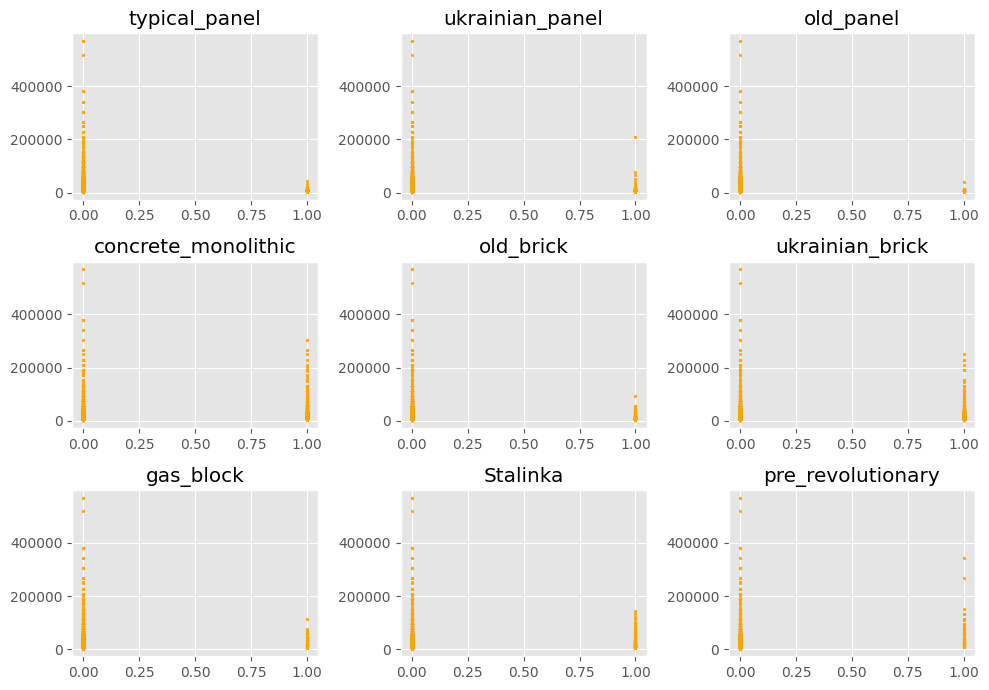

In [ ]:
building_details = [
    'typical_panel', 'ukrainian_panel',
    'old_panel', 'concrete_monolithic',
    'old_brick', 'ukrainian_brick',
    'gas_block', 'Stalinka', 'pre_revolutionary'
]

plt.figure(figsize=(10, 7))
for i, key in enumerate(building_details):
    plt.subplot(3, 3, i+1)
    plt.scatter(data_te_fir[key], data_te_fir["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
for col in building_details:
    print(data_te_fir[col].value_counts())
    print('\n')

typical_panel
0    6545
1     392
Name: count, dtype: int64


ukrainian_panel
0    6692
1     245
Name: count, dtype: int64


old_panel
0    6862
1      75
Name: count, dtype: int64


concrete_monolithic
0    5582
1    1355
Name: count, dtype: int64


old_brick
0    6646
1     291
Name: count, dtype: int64


ukrainian_brick
0    5618
1    1319
Name: count, dtype: int64


gas_block
0    6875
1      62
Name: count, dtype: int64


Stalinka
0    6695
1     242
Name: count, dtype: int64


pre_revolutionary
0    6764
1     173
Name: count, dtype: int64




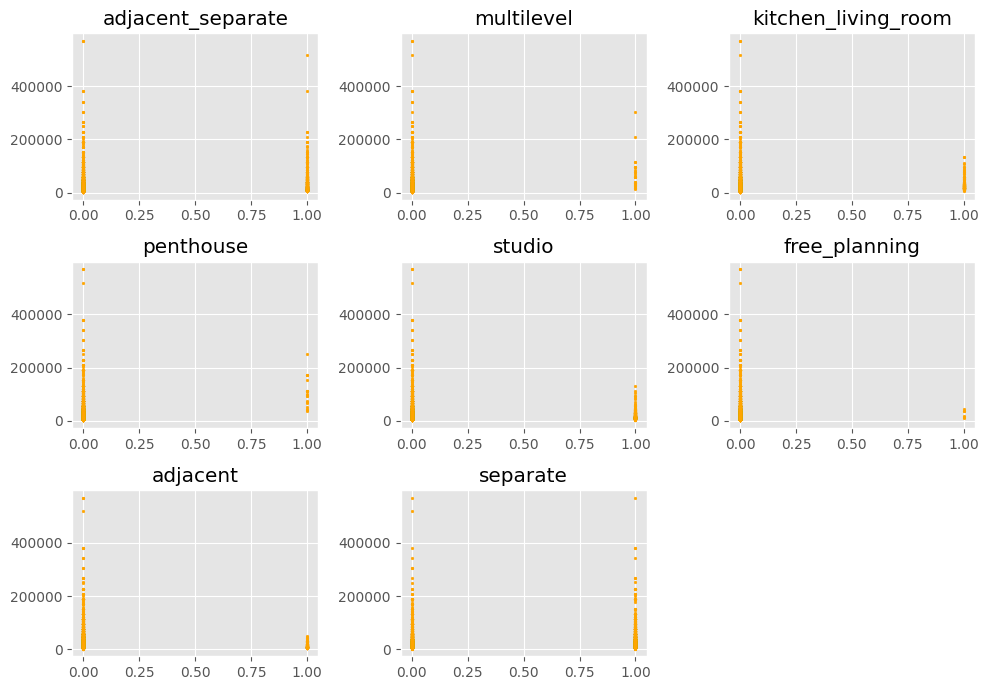

In [ ]:
features_planning = [
    'adjacent_separate', 'multilevel', 'kitchen_living_room',
    'penthouse', 'studio', 'free_planning', 'adjacent', 'separate']

plt.figure(figsize=(10, 7))
for i, key in enumerate(features_planning):
    plt.subplot(3, 3, i+1)
    plt.scatter(data_te_fir[key], data_te_fir["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
for col in features_planning:
    print(data_te_fir[col].value_counts())
    print('\n')

adjacent_separate
0    6186
1     751
Name: count, dtype: int64


multilevel
0    6906
1      31
Name: count, dtype: int64


kitchen_living_room
0    6748
1     189
Name: count, dtype: int64


penthouse
0    6917
1      20
Name: count, dtype: int64


studio
0    6473
1     464
Name: count, dtype: int64


free_planning
0    6931
1       6
Name: count, dtype: int64


adjacent
0    6752
1     185
Name: count, dtype: int64


separate
1    4265
0    2672
Name: count, dtype: int64




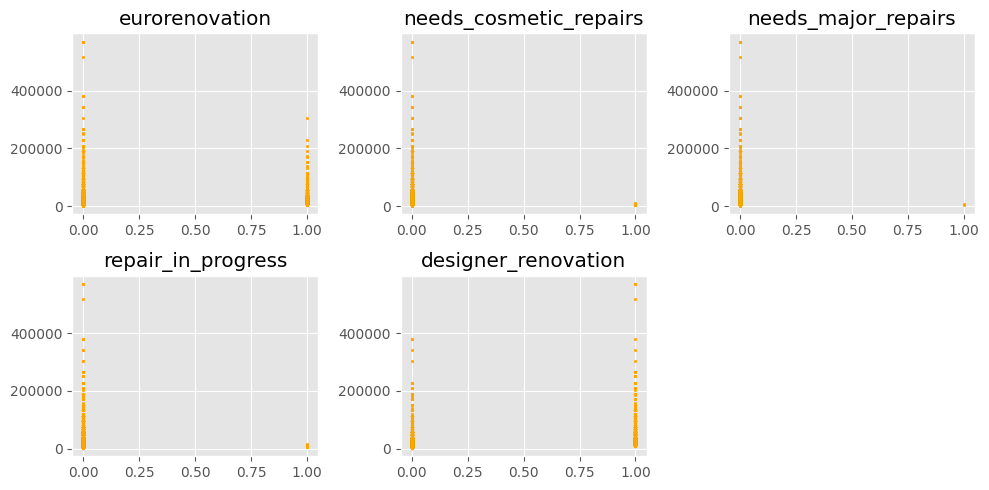

In [ ]:
repair_state = [
    'eurorenovation', 'needs_cosmetic_repairs', 'needs_major_repairs',
     'repair_in_progress', 'designer_renovation']

plt.figure(figsize=(10, 5))
for i, key in enumerate(repair_state):
    plt.subplot(2, 3, i+1)
    plt.scatter(data_te_fir[key], data_te_fir["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
for col in repair_state:
    print(data_te_fir[col].value_counts())
    print('\n')

eurorenovation
0    4380
1    2557
Name: count, dtype: int64


needs_cosmetic_repairs
0    6923
1      14
Name: count, dtype: int64


needs_major_repairs
0    6935
1       2
Name: count, dtype: int64


repair_in_progress
0    6932
1       5
Name: count, dtype: int64


designer_renovation
0    5634
1    1303
Name: count, dtype: int64




combine 'needs_cosmetic_repairs' and 'needs_major_repairs' to one colun 'needs_repair'

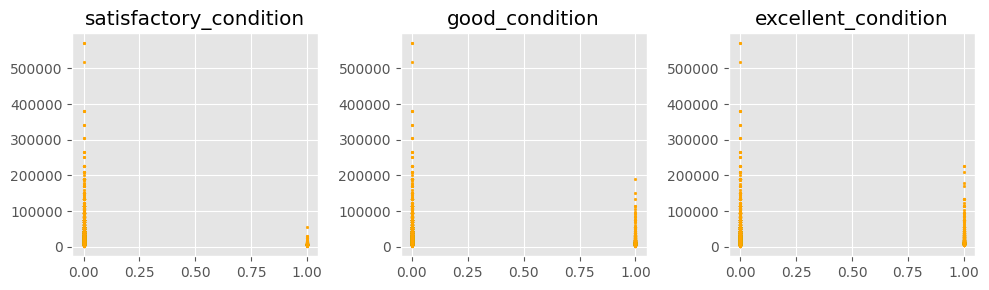

In [ ]:
condition = ['satisfactory_condition',
             'good_condition', 'excellent_condition']

plt.figure(figsize=(10, 3))
for i, key in enumerate(condition):
    plt.subplot(1, 3, i+1)
    plt.scatter(data_te_fir[key], data_te_fir["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
for col in condition:
    print(data_te_fir[col].value_counts())
    print('\n')

satisfactory_condition
0    6622
1     315
Name: count, dtype: int64


good_condition
0    5111
1    1826
Name: count, dtype: int64


excellent_condition
0    6185
1     752
Name: count, dtype: int64




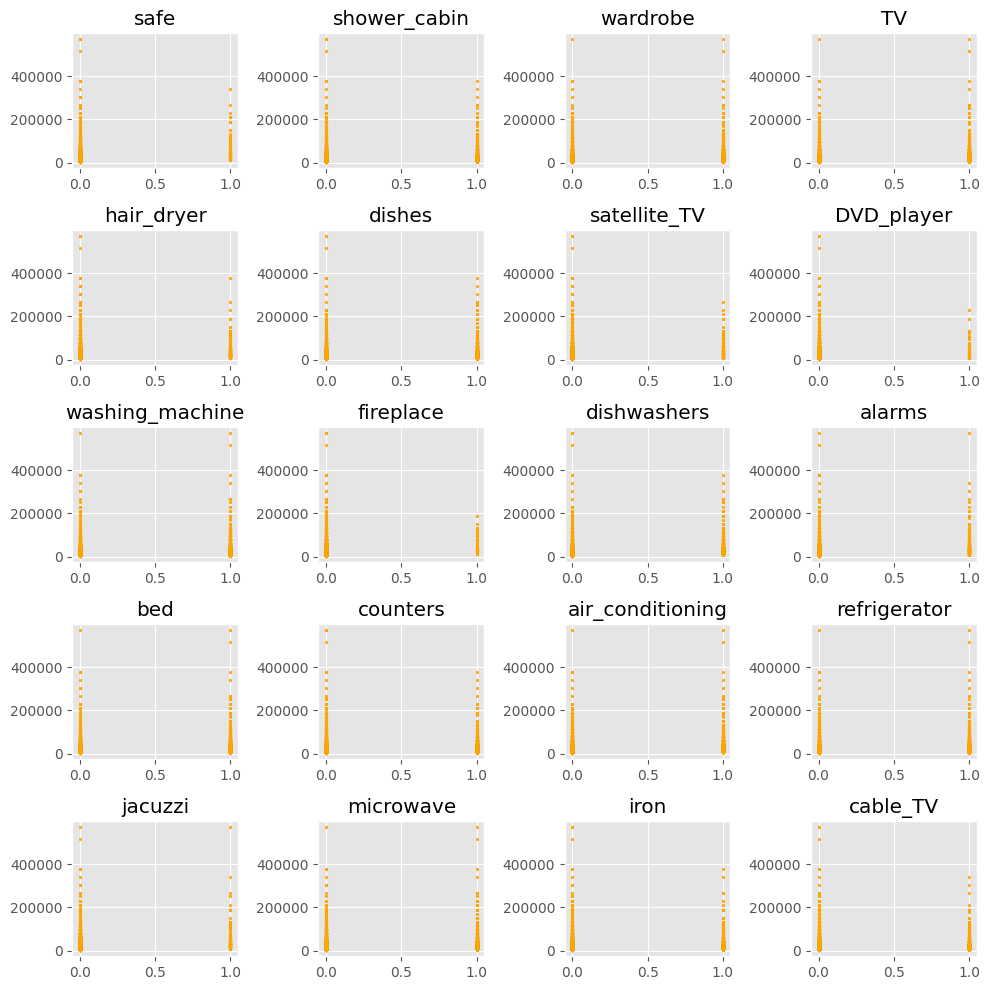

In [ ]:
facilities = [
    'safe', 'shower_cabin', 'wardrobe', 'TV',
     'hair_dryer', 'dishes', 'satellite_TV', 'DVD_player',
     'washing_machine', 'fireplace', 'dishwashers', 'alarms',
     'bed', 'counters', 'air_conditioning', 'refrigerator',
     'jacuzzi', 'microwave', 'iron', 'cable_TV'
]

plt.figure(figsize=(10, 10))
for i, key in enumerate(facilities):
    plt.subplot(5, 4, i+1)
    plt.scatter(data_te_fir[key], data_te_fir["price"], s=3, color='orange')
    plt.title(key)
plt.tight_layout()
plt.show()

In [ ]:
for col in facilities:
    print(data_te_fir[col].value_counts())
    print('\n')

safe
0    6780
1     157
Name: count, dtype: int64


shower_cabin
0    5873
1    1064
Name: count, dtype: int64


wardrobe
0    4048
1    2889
Name: count, dtype: int64


TV
0    4787
1    2150
Name: count, dtype: int64


hair_dryer
0    6585
1     352
Name: count, dtype: int64


dishes
0    5164
1    1773
Name: count, dtype: int64


satellite_TV
0    6687
1     250
Name: count, dtype: int64


DVD_player
0    6835
1     102
Name: count, dtype: int64


washing_machine
0    3897
1    3040
Name: count, dtype: int64


fireplace
0    6856
1      81
Name: count, dtype: int64


dishwashers
0    5841
1    1096
Name: count, dtype: int64


alarms
0    6418
1     519
Name: count, dtype: int64


bed
0    4183
1    2754
Name: count, dtype: int64


counters
0    4367
1    2570
Name: count, dtype: int64


air_conditioning
0    4826
1    2111
Name: count, dtype: int64


refrigerator
0    3853
1    3084
Name: count, dtype: int64


jacuzzi
0    6685
1     252
Name: count, dtype: int64


microwave
0    5

In [ ]:
black_list = ['id', 'price']
feats = [x for x in data.columns if x not in black_list]

X = data[feats].copy()

y = data['price'].copy()

transformer = ColumnTransformer(
    [('OneHot', OneHotEncoder(sparse_output=True), ['district']),
     ('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1, unknown_value=-1), ['subway'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_transform = transformer.fit_transform(X)
X_transform

def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

num_boost_round = 5_000

lgb_train = lgb.Dataset(X_transform, np.log1p(y),
                        #feature_name=feats,
                        free_raw_data=False)

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.1,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 100,
}

model = lgb.cv(
        params=parameters,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
        folds=kf,
        eval_train_metric=True,
        feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(100)]
    )


Training until validation scores don't improve for 20 rounds
[100]	cv_agg's train rmsle: 0.309419 + 0.00258303	cv_agg's valid rmsle: 0.316126 + 0.00770581
[200]	cv_agg's train rmsle: 0.293378 + 0.00252398	cv_agg's valid rmsle: 0.303251 + 0.00775791
[300]	cv_agg's train rmsle: 0.284067 + 0.00240408	cv_agg's valid rmsle: 0.296723 + 0.00799263
[400]	cv_agg's train rmsle: 0.277959 + 0.00232939	cv_agg's valid rmsle: 0.293451 + 0.00763725
[500]	cv_agg's train rmsle: 0.273446 + 0.00222651	cv_agg's valid rmsle: 0.290838 + 0.00797988
[600]	cv_agg's train rmsle: 0.269469 + 0.00216584	cv_agg's valid rmsle: 0.288964 + 0.00828416
[700]	cv_agg's train rmsle: 0.266189 + 0.00202178	cv_agg's valid rmsle: 0.288138 + 0.00827316
[800]	cv_agg's train rmsle: 0.263343 + 0.00199735	cv_agg's valid rmsle: 0.287065 + 0.00835289
Early stopping, best iteration is:
[814]	cv_agg's train rmsle: 0.262973 + 0.00199818	cv_agg's valid rmsle: 0.286836 + 0.00847392


In [ ]:
parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 10,
}

model = lgb.cv(
        parameters, lgb_train, num_boost_round, kf,
        eval_train_metric=True, feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(500)])


Training until validation scores don't improve for 10 rounds
[500]	cv_agg's train rmsle: 0.328618 + 0.00177099	cv_agg's valid rmsle: 0.333741 + 0.00864494
[1000]	cv_agg's train rmsle: 0.304717 + 0.0016332	cv_agg's valid rmsle: 0.313121 + 0.0075655
[1500]	cv_agg's train rmsle: 0.293887 + 0.00172822	cv_agg's valid rmsle: 0.304492 + 0.00759694
[2000]	cv_agg's train rmsle: 0.286238 + 0.00178264	cv_agg's valid rmsle: 0.299243 + 0.00777885
[2500]	cv_agg's train rmsle: 0.280255 + 0.00186728	cv_agg's valid rmsle: 0.295414 + 0.00789007
[3000]	cv_agg's train rmsle: 0.275313 + 0.00195212	cv_agg's valid rmsle: 0.292563 + 0.00789325
[3500]	cv_agg's train rmsle: 0.271099 + 0.00203197	cv_agg's valid rmsle: 0.290075 + 0.00794153
[4000]	cv_agg's train rmsle: 0.267436 + 0.00196262	cv_agg's valid rmsle: 0.288164 + 0.0081475
Early stopping, best iteration is:
[4245]	cv_agg's train rmsle: 0.265776 + 0.00198139	cv_agg's valid rmsle: 0.287367 + 0.00815705


In [ ]:
0.287367-0.265776

0.02159099999999997

In [ ]:
black_list = ['id', 'price']
feats = [x for x in data.columns if x not in black_list]

X = data[feats].copy()

y = data['price'].copy()

transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                 encoded_missing_value=-1, unknown_value=-1), ['subway', 'district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_transform = transformer.fit_transform(X)
X_transform

def rmsle_lgbm(y_pred, data):
    y_pred = np.expm1(y_pred)

    y_true = np.expm1(np.array(data.get_label()))
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

num_boost_round = 5_000

lgb_train = lgb.Dataset(X_transform, np.log1p(y),
                        #feature_name=feats,
                        free_raw_data=False)

parameters = {
    'objective': 'regression',
    'metric': 'custom',
    'learning_rate': 0.01,
    'random_state': 24,
    'verbose': 0,
    'force_col_wise': True,

    'num_leaves': 3,
    'max_depth': 5,

    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'min_data_in_leaf': 10,
}

model = lgb.cv(
        parameters, lgb_train, num_boost_round, kf,
        eval_train_metric=True, feval=rmsle_lgbm,
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(500)])


Training until validation scores don't improve for 10 rounds
[500]	cv_agg's train rmsle: 0.331115 + 0.001952	cv_agg's valid rmsle: 0.336689 + 0.00967084
[1000]	cv_agg's train rmsle: 0.30701 + 0.00178871	cv_agg's valid rmsle: 0.315995 + 0.00846577
[1500]	cv_agg's train rmsle: 0.295896 + 0.00189915	cv_agg's valid rmsle: 0.307146 + 0.00847409
[2000]	cv_agg's train rmsle: 0.287984 + 0.00192383	cv_agg's valid rmsle: 0.30147 + 0.00853752
[2500]	cv_agg's train rmsle: 0.28185 + 0.00189285	cv_agg's valid rmsle: 0.297293 + 0.00869213
[3000]	cv_agg's train rmsle: 0.276877 + 0.00200838	cv_agg's valid rmsle: 0.294207 + 0.0085737
[3500]	cv_agg's train rmsle: 0.272567 + 0.00202782	cv_agg's valid rmsle: 0.291706 + 0.00855373
[4000]	cv_agg's train rmsle: 0.268884 + 0.00202142	cv_agg's valid rmsle: 0.289819 + 0.0085166
[4500]	cv_agg's train rmsle: 0.265605 + 0.00204949	cv_agg's valid rmsle: 0.288298 + 0.00859592
Early stopping, best iteration is:
[4923]	cv_agg's train rmsle: 0.263094 + 0.0020413	cv_agg'

In [ ]:
# data = pd.read_csv('data/real_estate_last.csv')
black_list = ['id', 'price']
features = [col for col in data.columns if col not in black_list]

X = data[features]
y = np.log1p(data['price']).values

transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                 encoded_missing_value=-1,
                                 unknown_value=-1), ['subway', 'district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_lgb = {
    'num_leaves': 3,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 4925,
    'subsample': 0.6,
    'subsample_freq': 1,
    'colsample_bytree': 0.6,
    'random_state': 24,
    'force_col_wise': True,
    'min_child_samples': 10,
    'objective': 'regression',
}

model = lgb.LGBMRegressor(**parameters_lgb)

lgb_model = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

lgb_model.fit(X, y)

Pipeline(steps=[('transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('labelEnc',
                                                  OrdinalEncoder(encoded_missing_value=-1,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['subway', 'district'])],
                                   verbose_feature_names_out=False)),
                ('regr',
                 LGBMRegressor(colsample_bytree=0.6, force_col_wise=True,
                               learning_rate=0.01, max_depth=5,
                               min_child_samples=10, n_estimators=4925,
                               num_leaves=3, objective='regression',
                               random_state=24, subsample=0.6,
                               subsample_freq=1))])

In [ ]:


mapie_reg = MapieRegressor(estimator=lgb_model, cv=3, agg_function='median')
mapie_reg.fit(X, y)

joblib.dump(mapie_reg, '../data/mapie_reg.sav')




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=24)

In [ ]:
predictions = pd.DataFrame()

y_pred_mapie, y_pis = mapie_reg.predict(X_test, ensemble=True, alpha=0.3)

predictions['prediction'] = np.expm1(y_pred_mapie)
predictions['lower'] = np.expm1(y_pis.reshape(-1, 2)[:, 0])
predictions['upper'] = np.expm1(y_pis.reshape(-1, 2)[:, 1])
predictions['error_lower'] = (predictions['prediction']
                                  - predictions['lower'])
predictions['error_upper'] = (predictions['upper']
                                  - predictions['prediction'])
predictions['error'] = predictions.filter(regex='error').mean(axis=1)

In [ ]:
predictions['error']

0       2322.463258
1       2979.548345
2       1732.825048
3       2987.167220
4       2415.695801
           ...     
690     2075.953555
691     4969.145740
692    11540.944580
693     9504.929427
694     8211.904281
Name: error, Length: 695, dtype: float64

In [ ]:
X, y = get_X_y(data, feats)

transformer = ColumnTransformer(
    [('labelEnc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                 encoded_missing_value=-1,
                                 unknown_value=-1), ['subway', 'district'])],
    remainder='passthrough',
    verbose_feature_names_out=False
)

parameters_ctb = {
    #"loss_function": "Logloss",
    #"eval_metric": "AUC",
    "iterations": 1000,
    "learning_rate": 0.1,
    "random_seed": 24,
    "od_wait": 30,
    "od_type": "Iter",
    "thread_count": 4,

    "subsample": 0.6,
    "rsm": 0.6,
    "depth": 5,
    "l2_leaf_reg": 12,
    "verbose": False
}

model = ctb.CatBoostRegressor(**parameters_ctb)

ctb_model = Pipeline([
    ('transform', transformer),
    ('regr', model)
])

run_cv(ctb_model, X, y, folds=5, target_log=True, cv_type=StratifiedKFold, success_metric=rmsle_score)

[Fold 0] train_rmsle: 0.1779, test_rmsle: 0.2771
[Fold 1] train_rmsle: 0.1797, test_rmsle: 0.2709
[Fold 2] train_rmsle: 0.1798, test_rmsle: 0.2640
[Fold 3] train_rmsle: 0.1806, test_rmsle: 0.2638
[Fold 4] train_rmsle: 0.1804, test_rmsle: 0.2678
RMSLE: 0.2687 ± 0.0049
